In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LogNorm
import time as tm
from time import time
import fitsio
import pandas as pd
from galpy.potential import MWPotential2014, vcirc, evaluateRforces
from galpy.orbit import Orbit
from scipy.stats import gaussian_kde, ks_2samp, kstest
from hyppo.ksample import Energy, KSample
from hyppo.independence import Hsic
import corner
from scipy.stats import norm
from sklearn.mixture import GaussianMixture

from astroquery.gaia import Gaia
from astropy.table import Table
from astropy.table import Table, vstack
from glob import glob
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.linear_model import LinearRegression
import os
from datetime import datetime
from matplotlib.ticker import AutoLocator
from pathlib import Path
from functools import reduce



# Setup and helper functions moved to external module
from equations_file import *

# If you change the external module and want live reload during development, uncomment:
# %load_ext autoreload
# %autoreload 2

In [2]:
with fitsio.FITS(galah_Gaia_fits) as hdul1:
    data_1 = hdul1[1].read()
galah_Gaia_raw = pd.DataFrame(data_1)
galah_Gaia_raw = ensure_native_endian(galah_Gaia_raw)

In [5]:
galah_Gaia = galah_Gaia_raw[(galah_Gaia_raw['snr_px_ccd3'] > 30)       # Kushniruk 2026 also has cuts in log g and temp. I wonder if I should as well
                        & (galah_Gaia_raw['flag_sp'] == 0)
                        & (galah_Gaia_raw['flag_fe_h'] == 0)
                        & (galah_Gaia_raw['e_fe_h'] < 0.2)
                        & (galah_Gaia_raw['flag_sp_fit'] == 0)
                        & (galah_Gaia_raw['flag_red'] == 0)
                        & (galah_Gaia_raw['ruwe'] < 1.4)
                        & (galah_Gaia_raw['logg'] < 3.5)
                        & (galah_Gaia_raw['teff'] > 4000)
                        & (galah_Gaia_raw['teff'] < 6500)
                        # & (galah_Gaia_raw['flag_mg_fe'] == 0)
                        # & (galah_Gaia_raw['flag_na_fe'] == 0)
                        # & (galah_Gaia_raw['flag_cu_fe'] == 0)
                        & (galah_Gaia_raw['fe_h'] < -0.8)
                        # & (galah_Gaia_raw['fe_h'] < -1.25)
                        # & (galah_Gaia_raw['fe_h'] > -1.8)
                        # & (galah_Gaia_raw['ti_fe'] > 0.25)
                        
                        & (galah_Gaia_raw['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main',
                                                               'k2_hermes', 'galah_phase2', 'tess_hermes'
                                                               ]))
                        & (galah_Gaia_raw['radial_velocity'].notnull())
                        & (galah_Gaia_raw['ra_gaia'].notnull())
                        & (galah_Gaia_raw['dec_gaia'].notnull())
                        & (galah_Gaia_raw['pmra_gaia'].notnull())
                        & (galah_Gaia_raw['pmdec_gaia'].notnull())
                        & (galah_Gaia_raw['parallax_gaia'] > 0)
                        
    ]

print(f"Number of stars after cuts: {len(galah_Gaia)}")

Number of stars after cuts: 9106


In [6]:
NGC3201_galah = pd.merge( galah_Gaia, Vmans_NGC3201_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC5139_galah = pd.merge( galah_Gaia, Vmans_NGC5139_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')
NGC1851_galah = pd.merge( galah_Gaia, Vmans_NGC1851_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')   
NGC0104_galah = pd.merge( galah_Gaia, Vmans_NGC0104_high_prob, left_on = 'gaiadr3_source_id', right_on = 'source_id', how = 'inner')

galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)
                                #  & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                 & (galah_Gaia_raw['flag_mg_fe'] == 0)
                                 & (galah_Gaia_raw['flag_na_fe'] == 0)
                                 & (galah_Gaia_raw['flag_cu_fe'] == 0)
                                 & ((galah_Gaia_raw['mg_fe'] - galah_Gaia_raw['cu_fe']) - ((1.06923) * galah_Gaia_raw['na_fe']) > 0.40150)
                                 ]

# Kushniruk et al . 2026 https://doi.org/10.1051/0004-6361/202451201
galah_Kushniruk_Thamnos1 = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])- 13.5)**2) / (4.0**2)) + (((galah_Gaia['jphi'] + 600)**2) / (350**2)) < 1)
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                      ]

galah_Kushniruk_Thamnos2 = galah_Gaia[(((np.sqrt(galah_Gaia['jr'])-8.6)**2) / (3.5**2)) + (((galah_Gaia['jphi'] + 1184)**2) / (175**2)) < 1
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                        # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                                        # & (galah_Gaia['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main']))
                                      ]

# Feuillet et al. 2021 https://doi.org/10.1093/mnras/stab2614
galah_Gaia_GSE = galah_Gaia[GSE_cuts_Diane_2021(galah_Gaia)
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            ]

# Feuillet et al. 2021 https://doi.org/10.1093/mnras/stab2614
galah_Gaia_Sequoia = galah_Gaia[Sequoia_cuts_Diane_2021(galah_Gaia)
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id']))
                            # & (galah_Gaia_raw['y_fe'] < 0.8)
                            ]

galah_Gaia_Halo = galah_Gaia[(np.sqrt((galah_Gaia['vphi']-230)**2 + (galah_Gaia['vr'])**2 + (galah_Gaia['vz'])**2) > 230) # Koppelman et al. 2019  https://doi.org/10.1051/0004-6361/201936738
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id'])) 
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id'])) 
                            # & (galah_Gaia_raw['fe_h'] < -1.1)
                            # & (galah_Gaia_raw['fe_h'] > -1.9)
                             ]


/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_587/1748123235.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  galah_Kushniruk_GSE = galah_Gaia[((((np.sqrt(galah_Gaia['jr'])-35)**2) / (17.5**2)) + (((galah_Gaia['jphi'] + 130)**2) / (250**2)) < 1)



In [7]:
galah_Gaia_else = galah_Gaia_raw[(galah_Gaia_raw['snr_px_ccd3'] > 30)       # Kushniruk 2026 also has cuts in log g and temp. I wonder if I should as well
                        & (galah_Gaia_raw['flag_sp'] == 0)
                        & (galah_Gaia_raw['flag_fe_h'] == 0)
                        & (galah_Gaia_raw['e_fe_h'] < 0.2)
                        & (galah_Gaia_raw['flag_sp_fit'] == 0)
                        & (galah_Gaia_raw['flag_red'] == 0)
                        & (galah_Gaia_raw['ruwe'] < 1.4)
                        & (galah_Gaia_raw['logg'] < 3.5)
                        & (galah_Gaia_raw['teff'] > 4000)
                        & (galah_Gaia_raw['teff'] < 6500)
                        # & (galah_Gaia_raw['fe_h'] < -0.75)
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos1['gaiadr3_source_id']))
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Kushniruk_Thamnos2['gaiadr3_source_id'])) 
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Gaia_GSE['gaiadr3_source_id']))
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Gaia_Sequoia['gaiadr3_source_id'])) 
                        & (~galah_Gaia_raw['gaiadr3_source_id'].isin(galah_Gaia_Halo['gaiadr3_source_id']))
                        & (galah_Gaia_raw['survey_name'].isin(['galah_faint', 'galah_bright', 'galah_main',
                                                               'k2_hermes', 'galah_phase2', 'tess_hermes'
                                                               ]))
    ]

In [6]:
# df = galah_Gaia_Sequoia
# df = galah_Gaia_GSE
# df = NGC5139_galah
df = NGC0104_galah


survey_list = []
for i in df['survey_name'].unique():
    survey_list.append(i)

for i in survey_list:
    num = 0
    for j in df['survey_name']:
        if j == i:
            num += 1
    print(f'{i}:  {num}')

galah_main:  93


In [7]:
print(f'len(NGC3201_galah): {len(NGC3201_galah)}')
print(f'len(NGC5139_galah): {len(NGC5139_galah)}')
print(f'len(NGC1851_galah): {len(NGC1851_galah)}')
print(f'len(NGC0104_galah): {len(NGC0104_galah)}')
print(f'len(galah_Kushniruk_GSE): {len(galah_Kushniruk_GSE)}')
print(f'len(galah_Kushniruk_Thamnos1): {len(galah_Kushniruk_Thamnos1)}')
print(f'len(galah_Kushniruk_Thamnos2): {len(galah_Kushniruk_Thamnos2)}')
print(f'len(galah_Gaia_GSE): {len(galah_Gaia_GSE)}')
print(f'len(galah_Gaia_Sequoia): {len(galah_Gaia_Sequoia)}')
print(f'len(galah_Gaia_Halo): {len(galah_Gaia_Halo)}')
print(f'len(galah_Gaia_else): {len(galah_Gaia_else)}')

len(NGC3201_galah): 0
len(NGC5139_galah): 3
len(NGC1851_galah): 0
len(NGC0104_galah): 93
len(galah_Kushniruk_GSE): 686
len(galah_Kushniruk_Thamnos1): 218
len(galah_Kushniruk_Thamnos2): 19
len(galah_Gaia_GSE): 873
len(galah_Gaia_Sequoia): 127
len(galah_Gaia_Halo): 3329
len(galah_Gaia_else): 155909


In [8]:
galah_Gaia_else_C = "#110C0C"
Sequoia_C = '#d62728'
GSE_C = "#16b823d8"
Halo_C = "#0e35e2"

thamnos_1_C = "#96bd0b"
thamnos_2_C = '#C43DFF'

Text(0, 0.5, 'energy ($10^5$ km$^2$ s$^{-2}$)')

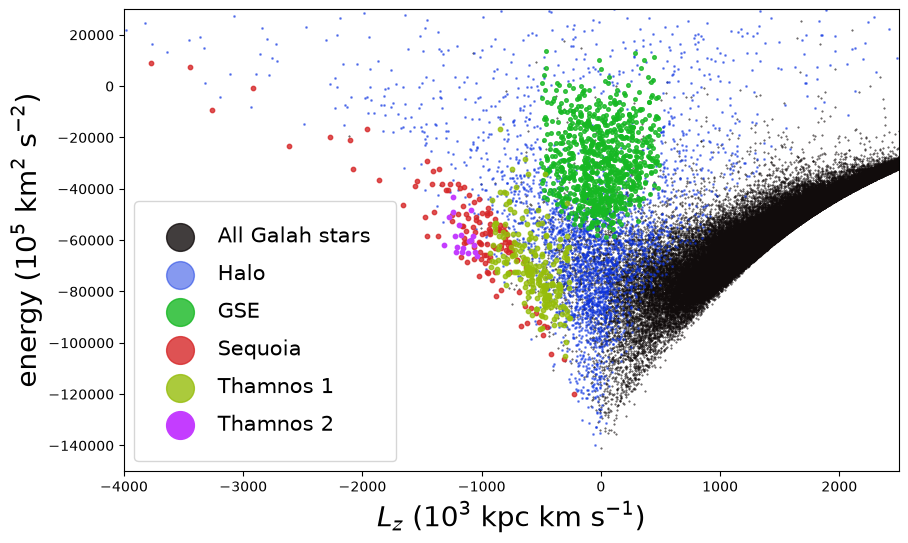

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(galah_Gaia_else['jphi'], galah_Gaia_else['energy'], label = 'All Galah stars', s = 0.2, alpha = 0.8, c = galah_Gaia_else_C)

plt.scatter(galah_Gaia_Halo['jphi'], galah_Gaia_Halo['energy'], label = 'Halo', s = 1, alpha = 0.5, c = Halo_C)
plt.scatter(galah_Gaia_GSE['jphi'], galah_Gaia_GSE['energy'], label = 'GSE', s = 7, alpha = 0.8, c = GSE_C)
plt.scatter(galah_Gaia_Sequoia['jphi'], galah_Gaia_Sequoia['energy'], label = 'Sequoia', s = 10, alpha = 0.8, c = Sequoia_C)


# plt.scatter(Sequoia_chem_selected['jphi'], Sequoia_chem_selected['energy'], label = 'chemically selected "Sequoia" stars', s = 5, alpha = 0.8, c = 'red')


# plt.scatter(galah_Kushniruk_GSE['jphi'], galah_Kushniruk_GSE['energy'], label = 'GSE', s = 0.3, alpha = 0.8, c = 'olive')
# plt.scatter(NGC5139_galah['jphi'], NGC5139_galah['energy'], label = "NGC5139",  s = 7, alpha = 0.8, c = 'orange')
plt.scatter(galah_Kushniruk_Thamnos1['jphi'], galah_Kushniruk_Thamnos1['energy'], label = 'Thamnos 1', s = 10, alpha = 0.8, c = thamnos_1_C)
plt.scatter(galah_Kushniruk_Thamnos2['jphi'], galah_Kushniruk_Thamnos2['energy'], label = 'Thamnos 2', s = 10, alpha = 1.0, c = thamnos_2_C)

# plt.scatter(NGC1851_galah['jphi'], NGC1851_galah['energy'], label = "galah_NGC1851",  s = 10, alpha = 0.5, c = 'b')
# plt.scatter(NGC0104_galah['jphi'], NGC0104_galah['energy'], label = "NGC0104",  s = 10, alpha = 0.5, c = 'pink')


plt.xlim(-4000, 2500)
plt.ylim(-150000,30000)
leg = plt.legend(fontsize=15, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    try:
        handle.set_sizes([400])
    except Exception:
        pass
plt.xlabel(r'$L_z$ ($10^3$ kpc km s$^{-1}$)', fontsize = 20)
plt.ylabel(r'energy ($10^5$ km$^2$ s$^{-2}$)', fontsize = 20)
# plt.title('Galah' , fontsize = 20)

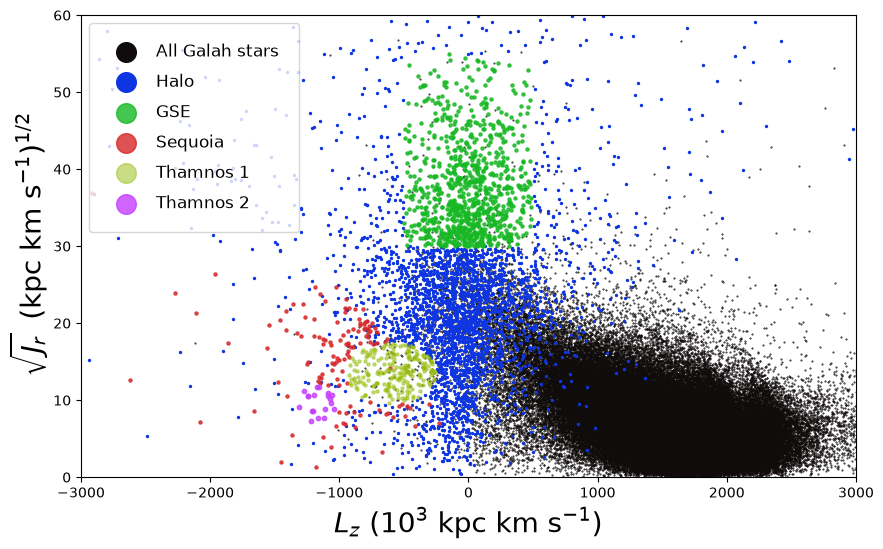

In [11]:
plt.figure(figsize=(10,6))

plt.scatter(galah_Gaia_else['jphi'], np.sqrt(galah_Gaia_else['jr']), label = 'All Galah stars', s = 0.2, alpha = 1.0, c = galah_Gaia_else_C)
plt.scatter(galah_Gaia_Halo['jphi'], np.sqrt(galah_Gaia_Halo['jr']), label = 'Halo', s = 2, alpha = 1.0, c = Halo_C)
plt.scatter(galah_Gaia_GSE['jphi'], np.sqrt(galah_Gaia_GSE['jr']), label = 'GSE', s = 5, alpha = 0.8, c = GSE_C)
plt.scatter(galah_Gaia_Sequoia['jphi'], np.sqrt(galah_Gaia_Sequoia['jr']), label = 'Sequoia', s = 5, alpha = 0.8, c = Sequoia_C)
# plt.scatter(NGC3201_galah['jphi'], np.sqrt(NGC3201_galah['jr']), label = 'NGC3201', s = 10, alpha = 0.8, c = 'purple')
# plt.scatter(NGC5139_galah['jphi'], np.sqrt(NGC5139_galah['jr']), label = 'NGC5139', s = 10, alpha = 0.8, c = 'orange')

# plt.scatter(galah_Kushniruk_GSE['jphi'], np.sqrt(galah_Kushniruk_GSE['jr']), label = 'GSE', s = 5, alpha = 0.8, c = 'g')
plt.scatter(galah_Kushniruk_Thamnos1['jphi'], np.sqrt(galah_Kushniruk_Thamnos1['jr']), label = 'Thamnos 1', s = 5, alpha = 0.5, c = thamnos_1_C)
plt.scatter(galah_Kushniruk_Thamnos2['jphi'], np.sqrt(galah_Kushniruk_Thamnos2['jr']), label = 'Thamnos 2', s = 10, alpha = 0.8, c = thamnos_2_C)

plt.xlim(-3000, 3000)
plt.ylim(0,60)
leg = plt.legend(fontsize=12, labelspacing=0.8, borderpad=1.2, loc='upper left')
for handle in leg.legend_handles:
    handle.set_sizes([200])
plt.xlabel(r'$L_z$ ($10^3$ kpc km s$^{-1}$)', fontsize = 20)
plt.ylabel(r'$\,\sqrt{J_r}\,$ (kpc km s$^{-1}$)$^{1/2}$', fontsize = 20);


Text(0, 0.5, '$\\sqrt{V_r^2 + V_z^2}$ (km s$^{-1}$)')

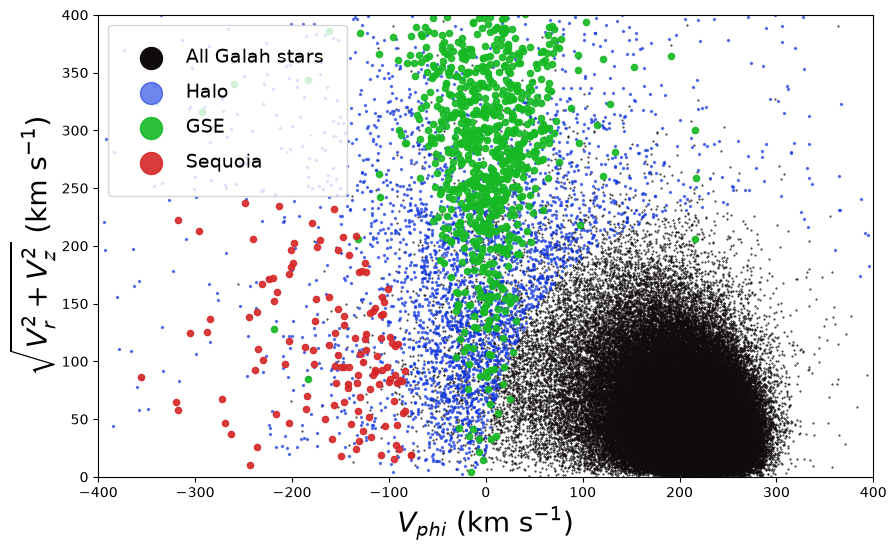

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(galah_Gaia_else['vphi'], np.sqrt((galah_Gaia_else['vr'])**2 + (galah_Gaia_else['vz'])**2), label = 'All Galah stars', s = 0.2, alpha = 1.0, c = galah_Gaia_else_C)
plt.scatter(galah_Gaia_Halo['vphi'], np.sqrt((galah_Gaia_Halo['vr'])**2 + (galah_Gaia_Halo['vz'])**2), label = 'Halo', s = 2, alpha = 0.6, c = Halo_C)
plt.scatter(galah_Gaia_GSE['vphi'], np.sqrt((galah_Gaia_GSE['vr'])**2 + (galah_Gaia_GSE['vz'])**2), label = 'GSE', s = 20, alpha = 0.9, c = GSE_C)
plt.scatter(galah_Gaia_Sequoia['vphi'], np.sqrt((galah_Gaia_Sequoia['vr'])**2 + (galah_Gaia_Sequoia['vz'])**2), label = 'Sequoia', s = 20, alpha = 0.9, c = Sequoia_C)
# plt.scatter(NGC3201_galah['vphi'], np.sqrt((NGC3201_galah['vr'])**2 + (NGC3201_galah['vz'])**2), label = 'NGC3201', s = 10, alpha = 0.8, c = 'orange')
# plt.scatter(NGC5139_galah['vphi'], np.sqrt((NGC5139_galah['vr'])**2 + (NGC5139_galah['vz'])**2), label = 'NGC5139', s = 10, alpha = 0.8, c = 'purple')

# plt.scatter(galah_Kushniruk_Thamnos1['vphi'], np.sqrt((galah_Kushniruk_Thamnos1['vr'])**2 + (galah_Kushniruk_Thamnos1['vz'])**2), label = 'Thamnos1', s = 10, alpha = 0.8, c = 'darkseagreen')
# plt.scatter(galah_Kushniruk_Thamnos2['vphi'], np.sqrt((galah_Kushniruk_Thamnos2['vr'])**2 + (galah_Kushniruk_Thamnos2['vz'])**2), label = 'Thamnos2', s = 10, alpha = 0.8, c = 'orange')

plt.xlim(-400, 400)
plt.ylim(0,400)
leg = plt.legend(fontsize=14, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([250])
plt.xlabel(r'$V_{phi}$ (km s$^{-1}$)', fontsize = 20)
plt.ylabel(r'$\sqrt{V_r^2 + V_z^2}$ (km s$^{-1}$)', fontsize=20)

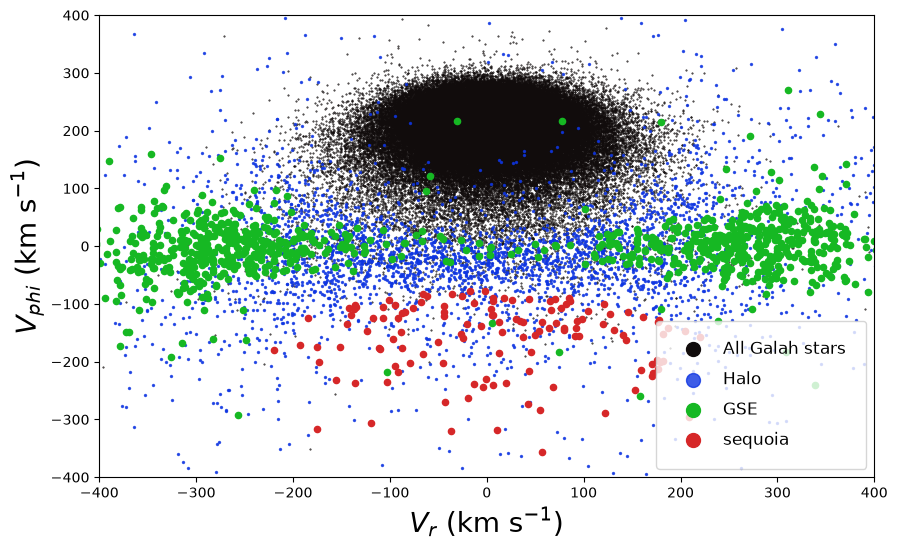

In [13]:
plt.figure(figsize=(10,6))

plt.scatter(galah_Gaia_else['vr'], galah_Gaia_else['vphi'],  label = 'All Galah stars', s = 0.2, alpha = 1.0, c = galah_Gaia_else_C)
plt.scatter(galah_Gaia_Halo['vr'], galah_Gaia_Halo['vphi'],  label = 'Halo', s = 2, alpha = 0.8, c = Halo_C)
plt.scatter(galah_Gaia_GSE['vr'], galah_Gaia_GSE['vphi'],  label = 'GSE', s = 20, alpha = 1.0, c = GSE_C)
plt.scatter(galah_Gaia_Sequoia['vr'], galah_Gaia_Sequoia['vphi'],  label = 'sequoia', s = 20, alpha = 1.0, c = Sequoia_C)
# plt.scatter(NGC3201_galah['vr'], NGC3201_galah['vphi'],  label = 'NGC3201', s = 10, alpha = 0.8, c = 'violet')
# plt.scatter(NGC5139_galah['vr'], NGC5139_galah['vphi'],  label = 'NGC5139', s = 10, alpha = 0.8, c = 'orange')

# plt.scatter(galah_Kushniruk_Thamnos1['vr'], galah_Kushniruk_Thamnos1['vphi'],  label = 'Thamnos1', s = 5, alpha = 0.8, c = 'k')
# plt.scatter(galah_Kushniruk_Thamnos2['vr'], galah_Kushniruk_Thamnos2['vphi'],  label = 'Thamnos2', s = 10, alpha = 0.8, c = 'orange')

plt.xlim(-400, 400)
plt.ylim(-400,400)
leg = plt.legend(fontsize=12, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([100])
plt.xlabel(r'$V_{r}$ (km s$^{-1}$)', fontsize = 20)
plt.ylabel(r'$V_{phi}$ (km s$^{-1}$)', fontsize = 20);

Text(0, 0.5, '($J_z$ - $J_r$) / $J_{tot}$')

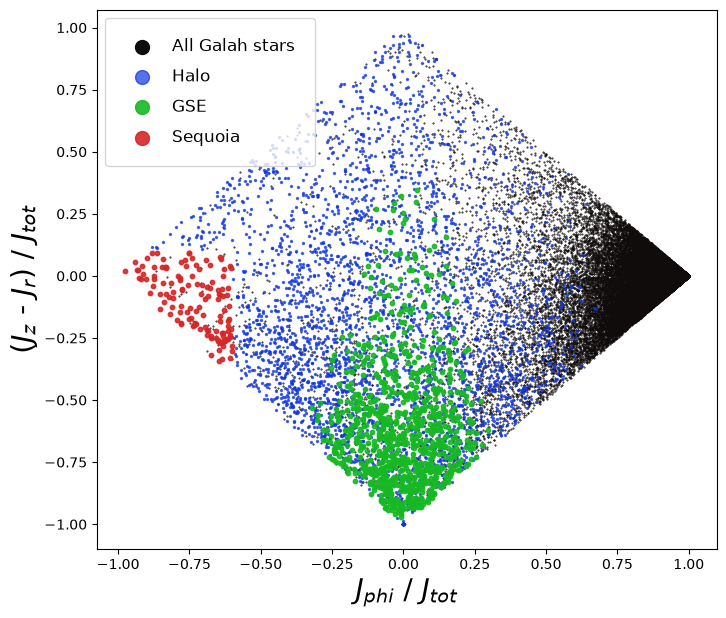

In [14]:
plt.figure(figsize=(8,7))

plt.scatter( galah_Gaia_else['jphi']/ galah_Gaia_else['jtot'], (galah_Gaia_else['jz'] - galah_Gaia_else['jr'])/galah_Gaia_else['jtot'], label = 'All Galah stars', s = 0.2, c = galah_Gaia_else_C, alpha = 1.0)
plt.scatter( galah_Gaia_Halo['jphi']/ galah_Gaia_Halo['jtot'], (galah_Gaia_Halo['jz'] - galah_Gaia_Halo['jr'])/galah_Gaia_Halo['jtot'], label = 'Halo', s = 2, c = Halo_C, alpha = 0.7)
plt.scatter( galah_Gaia_GSE['jphi']/ galah_Gaia_GSE['jtot'], (galah_Gaia_GSE['jz'] - galah_Gaia_GSE['jr'])/galah_Gaia_GSE['jtot'], label = 'GSE', c = GSE_C, s = 10, alpha  = 0.9)
plt.scatter( galah_Gaia_Sequoia['jphi']/ galah_Gaia_Sequoia['jtot'], (galah_Gaia_Sequoia['jz'] - galah_Gaia_Sequoia['jr'])/galah_Gaia_Sequoia['jtot'], label = 'Sequoia', c = Sequoia_C, s = 10, alpha = 0.9)#c = Apogee_Sequoia_new_ratios['mg_mn'], cmap = 'rainbow', s= 3, label = "Apogee_Sequoia")#, vmax  = 0)

# plt.scatter( Sequoia_chem_selected['jphi']/ Sequoia_chem_selected['jtot'], (Sequoia_chem_selected['jz'] - Sequoia_chem_selected['jr'])/Sequoia_chem_selected['jtot'], label = 'chemically selected "Sequoia" stars', c = 'r', s = 10, alpha = 0.9)#c = Apogee_Sequoia_new_ratios['mg_mn'], cmap = 'rainbow', s= 3, label = "Apogee_Sequoia")#, vmax  = 0)

# plt.scatter( galah_Kushniruk_Thamnos1['jphi']/ galah_Kushniruk_Thamnos1['jtot'], (galah_Kushniruk_Thamnos1['jz'] - galah_Kushniruk_Thamnos1['jr'])/galah_Kushniruk_Thamnos1['jtot'], label = 'Thamnos 1', c = 'darkseagreen', s = 10, alpha = 0.9)

leg = plt.legend(fontsize=12, labelspacing=0.8, borderpad=1.2)
for handle in leg.legend_handles:
    handle.set_sizes([100])
plt.xlabel(r'$J_{phi}$ / $J_{tot}$', fontsize = 20)
plt.ylabel(r'($J_z$ - $J_r$) / $J_{tot}$', fontsize = 20)
# plt.colorbar()

[-1.59436735]
Means: [-1.32067846]
Standard deviations: [0.33908476]
Weights: [1.]
Maximum PDF value: 1.1765223923243142


Text(0, 0.5, 'density')

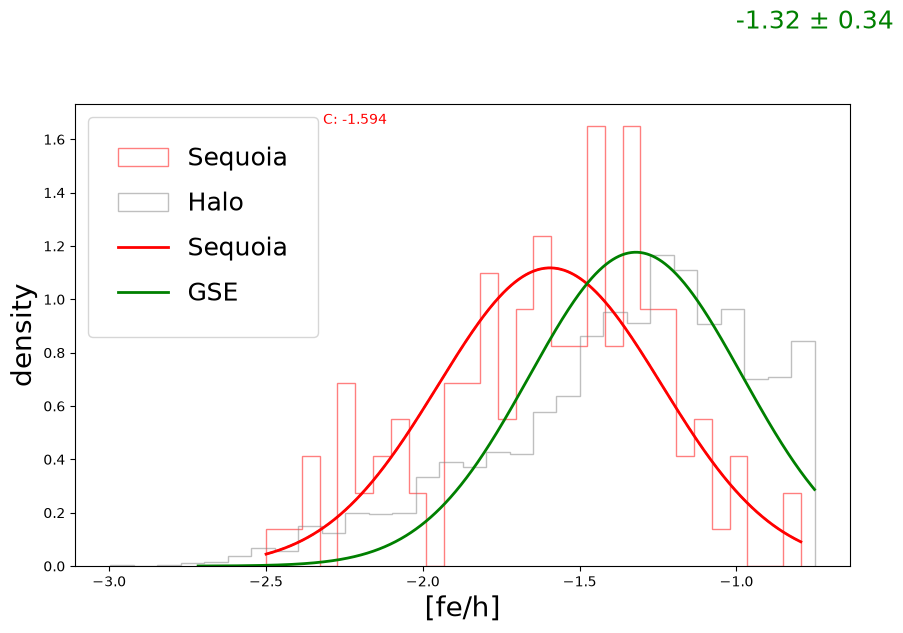

In [15]:
plt.figure(figsize=(10, 6))
elm_ratio = 'fe_h'
n_components = 1
shift_right = 0.32
fontsize = 18

elm_lable = elm_ratio
for i in elm_lable:
    if i == '_':
        elm_lable = elm_lable.replace('_', '/')


plt.hist(galah_Gaia_Sequoia[elm_ratio].dropna(), bins=30, color = 'r', alpha=0.5, label='Sequoia', density=True, histtype='step')
# plt.hist(galah_Gaia_GSE[elm_ratio].dropna(), bins=30, color = 'g', density=True, histtype='step')
plt.hist(galah_Gaia_Halo[elm_ratio].dropna(), bins=30, color = 'grey', alpha=0.5, label='Halo', density=True, histtype='step')
plot_gmm(galah_Gaia_Sequoia[elm_ratio].dropna(), f'Sequoia', n_components = n_components, color='r', maximum_peak=False, plot_compents = True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.91)
plot_gmm(galah_Gaia_GSE[elm_ratio].dropna(), f'GSE', n_components = n_components, color='g', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.81)
# plot_gmm(galah_Gaia_Halo[elm_ratio].dropna(), f'Halo', n_components = n_components, color='blue', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.71)


# galah_Kushniruk_Thamnos1_mask = (galah_Kushniruk_Thamnos1['fe_h'] <-0.75)
# plt.hist(galah_Kushniruk_Thamnos1[galah_Kushniruk_Thamnos1_mask][elm_ratio].dropna(), bins=30, color = 'darkseagreen', alpha=0.5, label='Thamnos', density=True, histtype='step')
# plot_gmm(galah_Kushniruk_Thamnos1[galah_Kushniruk_Thamnos1_mask][elm_ratio].dropna(), f'Halo', n_components = 3, color='darkseagreen', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.61)

leg = plt.legend(fontsize=18, labelspacing=0.8, borderpad=1.2, loc = 'upper left')
# for handle in leg.legend_handles:
    # handle.set_sizes([100])
plt.xlabel(f'[{elm_lable}]', fontsize = 20)
plt.ylabel('density', fontsize = 20)


In [16]:

element_list_partial_small_galah_7 = [ 'fe', 'cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_2 = ['cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_3 = ['fe', 'v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_7_4 = ['fe', 'si', 'nd', 'na', 'mg', 'k', 'ca', 'sc', 'ti', 'v', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba']
element_list_partial_small_galah_7_5 = ['v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']  # now I wonder if I could use sm_fe, o_fe, 
element_list_partial_small_galah_10 = ['fe', 'v', 'sc', 'si', 'ca', 'mn', 'na', 'nd']                                                             # and/or la_fe
element_list_partial_small_galah_11 = ['y', 'ba', 'nd', 'eu']                                                                                     # also la and sm would bring me to (50, 45, or 44combined)/65 sequoia stars otherwise
ASA_Plots_ratios = ['fe', 'si', 'ca', 'ti', 'mn', 'ni', 'y', 'nd']

element_list = ASA_Plots_ratios
element_list = element_list_partial_small_galah_7_5


galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia, element_list)

galah_Gaia_new_ratios = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0] # this ontains a full catalog from galah but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
galah_gaia_new_element_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]     # this just lists the new columns ratios so I can more easily call them
galah_gaia_new_element_ratio_errors_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[2] 

galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_GSE, element_list)
galah_Gaia_GSE_new_ratios = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_GSE, element_list)
galah_Gaia_Kushniruk_GSE_new_ratios = galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Sequoia, element_list)
galah_Gaia_Sequoia_new_ratios = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC3201_galah, element_list)
# galah_Gaia_NGC3201_new_ratios = galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC5139_galah, element_list)
galah_Gaia_NGC5139_new_ratios = galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos1, element_list)
galah_Gaia_Thamnos1_new_ratios = galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos2, element_list)
galah_Gaia_Thamnos2_new_ratios = galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC1851_galah, element_list)
# galah_Gaia_NGC1851_new_ratios = galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Halo, element_list)
galah_Gaia_Halo_new_ratios = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_else_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_else, element_list)
galah_Gaia_else_new_ratios = galah_Gaia_else_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_raw_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_raw, element_list)
galah_Gaia_raw_new_ratios = galah_Gaia_raw_new_ratios_catolog_ratiolist_ratioerrorlist[0]

/Users/simoncorrera/Desktop/MQ NGC3201 project copy/Jupyter Notebooks/equations_file.py:624: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_set_flagged[new_ratio_label] = data_set_flagged[col_name_for_numerator] - data_set_flagged[col_name_for_denominator] # this adds a new column to galah's catalog. It give the column the name and finds the ratio values

/Users/simoncorrera/Desktop/MQ NGC3201 project copy/Jupyter Notebooks/equations_file.py:623: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  

/Users/simoncorrera/Desktop/MQ 

In [17]:
Halo_Pradosh_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)
                                            # & (galah_Gaia_new_ratios['ti_fe'] > 0.25)
                                            & (galah_Gaia_new_ratios['Lz'] > -1500)
                                            & (galah_Gaia_new_ratios['Lz'] < 1500)
                                            & (galah_Gaia_new_ratios['ecc_gaia'] > 0.5)
                                            & (galah_Gaia_new_ratios['ecc_gaia'] < 0.8)
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE_new_ratios['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia_new_ratios['gaiadr3_source_id']))
                                            # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
                                            & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
                                            ]

thickdisk_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)
                                                 & (galah_Gaia_new_ratios['ti_fe'] > 0.25)
                                                 & (galah_Gaia_new_ratios['Lz'] > 0)
                                                 & (galah_Gaia_new_ratios['ecc_gaia'] < 0.5)
                                                #  & (~galah_Gaia['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_GSE_new_ratios['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_Sequoia_new_ratios['gaiadr3_source_id']))
                                                # & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC3201_new_ratios['gaiadr3_source_id']))
                                                & (~galah_Gaia['gaiadr3_source_id'].isin(galah_Gaia_NGC5139_new_ratios['gaiadr3_source_id']))
                                            ]
print(len(Halo_Pradosh_galah_Gaia))
print(len(thickdisk_galah_Gaia))

/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_22579/524127665.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  Halo_Pradosh_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)

/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_22579/524127665.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  thickdisk_galah_Gaia = galah_Gaia_new_ratios[(galah_Gaia_new_ratios['fe_h'] < -0.8)

1491
1932


In [18]:
print(f'len(galah_Gaia_Sequoia_new_ratios): {len(galah_Gaia_Sequoia_new_ratios)}')
print(f'len(galah_Gaia_GSE_new_ratios): {len(galah_Gaia_GSE_new_ratios)}')
print(f'len(galah_Gaia_Halo_new_ratios): {len(galah_Gaia_Halo_new_ratios)}')
print(f'len(galah_Gaia_else_new_ratios): {len(galah_Gaia_else_new_ratios)}')
print(f'len(galah_Gaia_raw_new_ratios): {len(galah_Gaia_raw_new_ratios)}')


len(galah_Gaia_Sequoia_new_ratios): 65
len(galah_Gaia_GSE_new_ratios): 527
len(galah_Gaia_Halo_new_ratios): 2026
len(galah_Gaia_else_new_ratios): 136101
len(galah_Gaia_raw_new_ratios): 376989


Means: [-1.43590457]
Standard deviations: [0.24594042]
Weights: [1.]
Maximum PDF value: 1.6221062163540971
Means: [-1.21657745]
Standard deviations: [0.26037948]
Weights: [1.]
Maximum PDF value: 1.532152039316941
Means: [-1.20972814]
Standard deviations: [0.2874136]
Weights: [1.]
Maximum PDF value: 1.3880400219949283
Means: [-1.22003638]
Standard deviations: [0.29062867]
Weights: [1.]
Maximum PDF value: 1.3726855820305086


Text(0, 0.5, 'density')

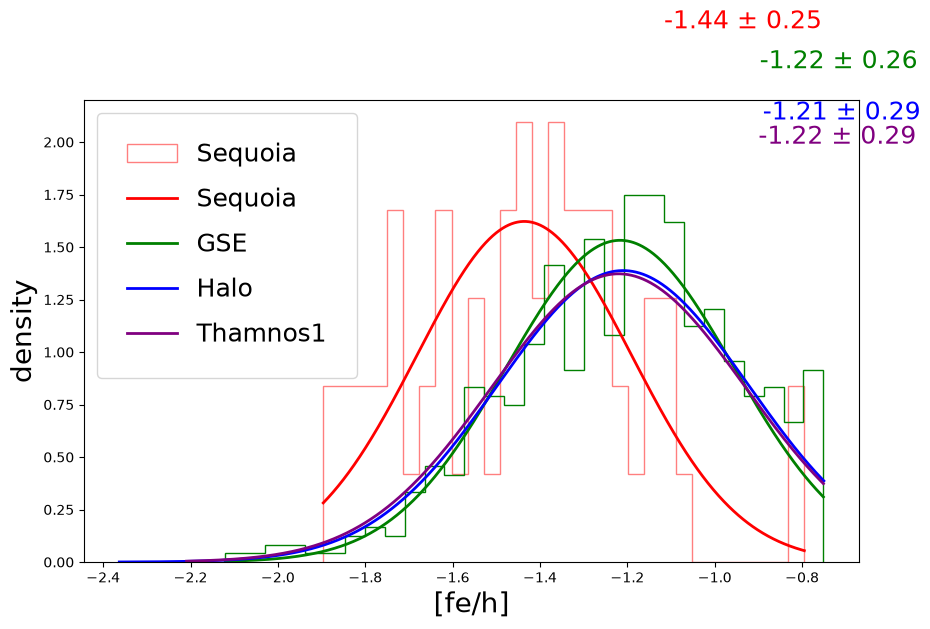

In [19]:
plt.figure(figsize=(10, 6))
elm_ratio = 'fe_h'
n_components = 1
shift_right = 0.32
fontsize = 18

elm_lable = elm_ratio
for i in elm_lable:
    if i == '_':
        elm_lable = elm_lable.replace('_', '/')

# plt.hist(galah_Gaia_Sequoia[elm_ratio].dropna(), bins=30, color = 'r', alpha=0.5, label='Sequoia', density=True, histtype='step')
plt.hist(galah_Gaia_Sequoia_new_ratios[elm_ratio].dropna(), bins=30, color = 'r', alpha=0.5, label='Sequoia', density=True, histtype='step')

plt.hist(galah_Gaia_GSE_new_ratios[elm_ratio].dropna(), bins=30, color = 'g', density=True, histtype='step')
# plt.hist(galah_Gaia_Halo_new_ratios[elm_ratio].dropna(), bins=30, color = 'grey', alpha=0.5, label='Halo', density=True, histtype='step')
# plt.hist(Halo_Pradosh_galah_Gaia[elm_ratio].dropna(), bins=30, color = 'grey', alpha=0.5, label='Halo', density=True, histtype='step')

plot_gmm(galah_Gaia_Sequoia_new_ratios[elm_ratio].dropna(), f'Sequoia', n_components = n_components, color='r', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.91)
plot_gmm(galah_Gaia_GSE_new_ratios[elm_ratio].dropna(), f'GSE', n_components = n_components, color='g', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.81)
plot_gmm(galah_Gaia_Halo_new_ratios[elm_ratio].dropna(), f'Halo', n_components = n_components, color='blue', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.71)
plot_gmm(galah_Gaia_Thamnos1_new_ratios[elm_ratio].dropna(), f'Thamnos1', n_components = n_components, color='purple', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.61)


# galah_Kushniruk_Thamnos1_mask = (galah_Kushniruk_Thamnos1['fe_h'] <-0.75)
# plt.hist(galah_Kushniruk_Thamnos1[galah_Kushniruk_Thamnos1_mask][elm_ratio].dropna(), bins=30, color = 'darkseagreen', alpha=0.5, label='Thamnos', density=True, histtype='step')
# plot_gmm(galah_Kushniruk_Thamnos1[galah_Kushniruk_Thamnos1_mask][elm_ratio].dropna(), f'Halo', n_components = 3, color='darkseagreen', maximum_peak=True, fontsize = fontsize, shift_right=shift_right, shift_up= 0.61)

leg = plt.legend(fontsize=18, labelspacing=0.8, borderpad=1.2, loc = 'upper left')
# for handle in leg.legend_handles:
    # handle.set_sizes([100])
plt.xlabel(f'[{elm_lable}]', fontsize = 20)
plt.ylabel('density', fontsize = 20)



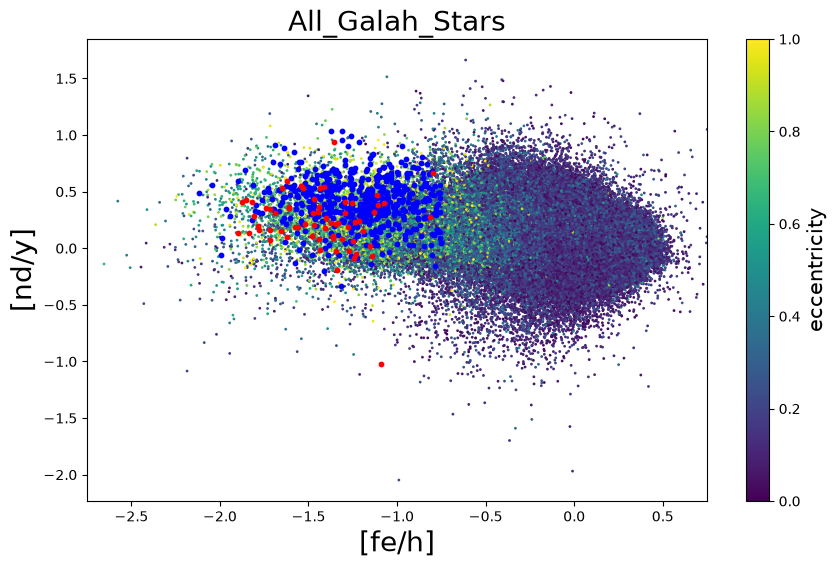

In [20]:
plt.figure(figsize=(10, 6))

elm_ratio1 = 'fe_h'
elm_ratio2 = 'nd_y'

elm_lable_x = elm_ratio1
elm_lable_y = elm_ratio2
for i in elm_lable_x:
    if i == '_':
        elm_lable_x = elm_lable_x.replace('_', '/')

for i in elm_lable_y:
    if i == '_':
        elm_lable_y = elm_lable_y.replace('_', '/')

plt.scatter(galah_Gaia_raw_new_ratios[elm_ratio1], galah_Gaia_raw_new_ratios[elm_ratio2], 
            c = galah_Gaia_raw_new_ratios['ecc_gaia'], #vmin = 0, vmax = 1,
            # c = 'k',
            label = 'All Galah', s = 1, alpha = 1)
plt.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = 'b', label = 'GSE', s = 10)
plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'r', label = 'Sequoia', s = 10)


plt.title('All_Galah_Stars', fontsize = 20)
plt.xlabel(F'[{elm_lable_x}]', fontsize = 20)
plt.ylabel(F'[{elm_lable_y}]', fontsize  = 20)

# plt.xlabel(F'[Fe/H]', fontsize = 20)
# plt.ylabel(F'[Si/Fe]', fontsize  = 20)
# leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
# for handle in leg.legend_handles:
#     handle.set_sizes([30])
plt.xlim(-2.75,0.75)
cbar = plt.colorbar()
cbar.set_label('eccentricity', fontsize = 15)


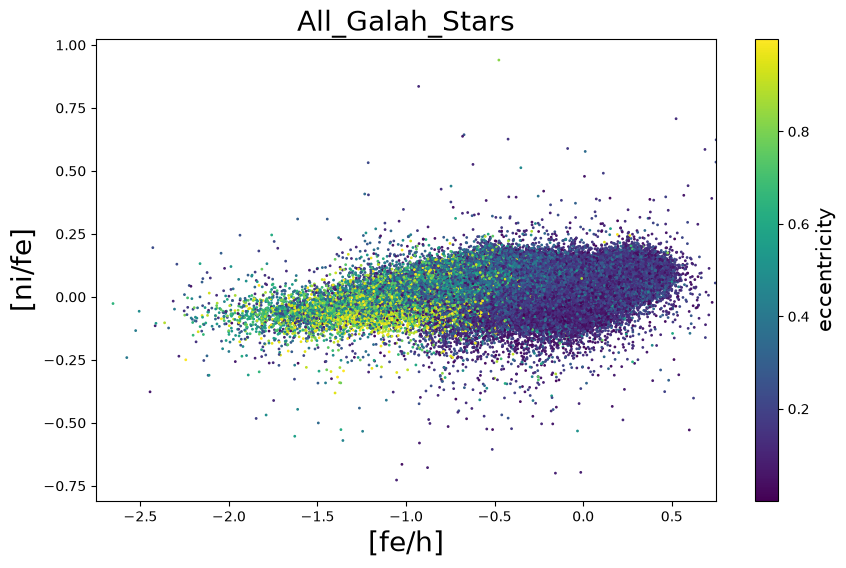

In [21]:
plt.figure(figsize=(10, 6))

elm_ratio1 = 'fe_h'
elm_ratio2 = 'ni_fe'

elm_lable_x = elm_ratio1
elm_lable_y = elm_ratio2
for i in elm_lable_x:
    if i == '_':
        elm_lable_x = elm_lable_x.replace('_', '/')

for i in elm_lable_y:
    if i == '_':
        elm_lable_y = elm_lable_y.replace('_', '/')

plt.scatter(galah_Gaia_raw_new_ratios[elm_ratio1], galah_Gaia_raw_new_ratios[elm_ratio2], 
            c = galah_Gaia_raw_new_ratios['ecc_gaia'], #vmin = 0, vmax = 1,
            # c = 'k',
            label = 'All Galah', s = 1, alpha = 1)
# plt.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = 'g', label = 'GSE', s = 10)
# plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'r', label = 'Sequoia', s = 10)


plt.title('All_Galah_Stars', fontsize = 20)
plt.xlabel(F'[{elm_lable_x}]', fontsize = 20)
plt.ylabel(F'[{elm_lable_y}]', fontsize  = 20)

# plt.xlabel(F'[Fe/H]', fontsize = 20)
# plt.ylabel(F'[Ni/Fe]', fontsize  = 20)
# leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
# for handle in leg.legend_handles:
#     handle.set_sizes([30])
plt.xlim(-2.75,0.75)
cbar = plt.colorbar()
cbar.set_label('eccentricity', fontsize = 15)


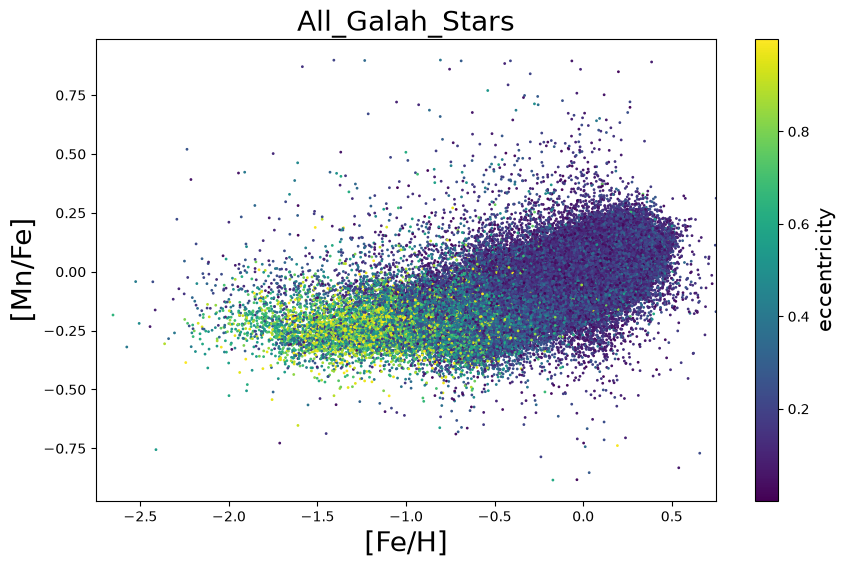

In [22]:
plt.figure(figsize=(10, 6))

elm_ratio1 = 'fe_h'
elm_ratio2 = 'mn_fe'

elm_lable_x = elm_ratio1
elm_lable_y = elm_ratio2
for i in elm_lable_x:
    if i == '_':
        elm_lable_x = elm_lable_x.replace('_', '/')

for i in elm_lable_y:
    if i == '_':
        elm_lable_y = elm_lable_y.replace('_', '/')

plt.scatter(galah_Gaia_raw_new_ratios[elm_ratio1], galah_Gaia_raw_new_ratios[elm_ratio2], 
            c = galah_Gaia_raw_new_ratios['ecc_gaia'], #vmin = 0, vmax = 1,
            # c = 'k',
            label = 'All Galah', s = 1, alpha = 1)
# plt.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = 'g', label = 'GSE', s = 10)
# plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'r', label = 'Sequoia', s = 10)


plt.title('All_Galah_Stars', fontsize = 20)
plt.xlabel(F'[{elm_lable_x}]', fontsize = 20)
plt.ylabel(F'[{elm_lable_y}]', fontsize  = 20)

plt.xlabel(F'[Fe/H]', fontsize = 20)
plt.ylabel(F'[Mn/Fe]', fontsize  = 20)
# leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
# for handle in leg.legend_handles:
#     handle.set_sizes([30])
plt.xlim(-2.75,0.75)
cbar = plt.colorbar()
cbar.set_label('eccentricity', fontsize = 15)


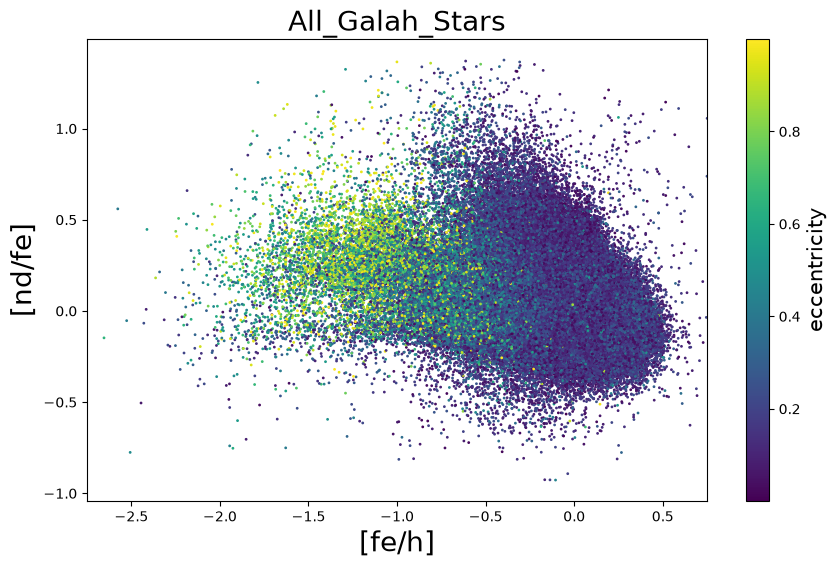

In [23]:
plt.figure(figsize=(10, 6))

elm_ratio1 = 'fe_h'
elm_ratio2 = 'nd_fe'

elm_lable_x = elm_ratio1
elm_lable_y = elm_ratio2
for i in elm_lable_x:
    if i == '_':
        elm_lable_x = elm_lable_x.replace('_', '/')

for i in elm_lable_y:
    if i == '_':
        elm_lable_y = elm_lable_y.replace('_', '/')

plt.scatter(galah_Gaia_raw_new_ratios[elm_ratio1], galah_Gaia_raw_new_ratios[elm_ratio2], 
            c = galah_Gaia_raw_new_ratios['ecc_gaia'], #vmin = 0, vmax = 1,
            # c = 'k',
            label = 'All Galah', s = 1, alpha = 1)
# plt.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = 'g', label = 'GSE', s = 10)
# plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'r', label = 'Sequoia', s = 10)


plt.title('All_Galah_Stars', fontsize = 20)
plt.xlabel(F'[{elm_lable_x}]', fontsize = 20)
plt.ylabel(F'[{elm_lable_y}]', fontsize  = 20)
# leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
# for handle in leg.legend_handles:
#     handle.set_sizes([30])
plt.xlim(-2.75,0.75)
cbar = plt.colorbar()
cbar.set_label('eccentricity', fontsize = 15)


In [24]:

element_list_partial_small_galah_7 = [ 'fe', 'cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_2 = ['cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_3 = ['fe', 'v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_7_4 = ['fe', 'si', 'nd', 'na', 'mg', 'k', 'ca', 'sc', 'ti', 'v', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba']
element_list_partial_small_galah_7_5 = ['v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_10 = ['fe', 'v', 'sc', 'si', 'ca', 'mn', 'na', 'nd']
element_list_partial_small_galah_11 = ['y', 'ba', 'nd', 'eu']

element_list = element_list_partial_small_galah_7_5
# element_list = element_list_partial_small_galah_10

galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia, element_list)

galah_Gaia_new_ratios = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0] # this ontains a full catalog from galah but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
galah_gaia_new_element_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]     # this just lists the new columns ratios so I can more easily call them
galah_gaia_new_element_ratio_errors_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[2] 

galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_GSE, element_list)
galah_Gaia_GSE_new_ratios = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_GSE, element_list)
galah_Gaia_Kushniruk_GSE_new_ratios = galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Sequoia, element_list)
galah_Gaia_Sequoia_new_ratios = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC3201_galah, element_list)
# galah_Gaia_NGC3201_new_ratios = galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC5139_galah, element_list)
# galah_Gaia_NGC5139_new_ratios = galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos1, element_list)
# galah_Gaia_Thamnos1_new_ratios = galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos2, element_list)
# galah_Gaia_Thamnos2_new_ratios = galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC1851_galah, element_list)
# galah_Gaia_NGC1851_new_ratios = galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Halo, element_list)
galah_Gaia_Halo_new_ratios = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_else_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_else, element_list)
galah_Gaia_else_new_ratios = galah_Gaia_else_new_ratios_catolog_ratiolist_ratioerrorlist[0]

/Users/simoncorrera/Desktop/MQ NGC3201 project copy/Jupyter Notebooks/equations_file.py:624: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data_set_flagged[new_ratio_label] = data_set_flagged[col_name_for_numerator] - data_set_flagged[col_name_for_denominator] # this adds a new column to galah's catalog. It give the column the name and finds the ratio values

/Users/simoncorrera/Desktop/MQ NGC3201 project copy/Jupyter Notebooks/equations_file.py:623: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  

/Users/simoncorrera/Desktop/MQ 

In [25]:
print(f'len(galah_Gaia_Sequoia_new_ratios): {len(galah_Gaia_Sequoia_new_ratios)}')
print(f'len(galah_Gaia_GSE_new_ratios): {len(galah_Gaia_GSE_new_ratios)}')
print(f'len(galah_Gaia_Halo_new_ratios): {len(galah_Gaia_Halo_new_ratios)}')
print(f'len(galah_Gaia_else_new_ratios): {len(galah_Gaia_else_new_ratios)}')


len(galah_Gaia_Sequoia_new_ratios): 65
len(galah_Gaia_GSE_new_ratios): 527
len(galah_Gaia_Halo_new_ratios): 2026
len(galah_Gaia_else_new_ratios): 136101


In [26]:
for df in [
    galah_Gaia_Sequoia_new_ratios,
    galah_Gaia_GSE_new_ratios,
    galah_Gaia_Halo_new_ratios,
    galah_Gaia_else_new_ratios,
]:
    df['v_si'] = -df['si_v']

/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_22579/3330799219.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['v_si'] = -df['si_v']



In [27]:
ratio1 = 'na_sc'
ratio2 = 'si_v'
# ratio3 = 'ti_v'
ratio4 = 'co_ca'
ratio5 = 'cr_k'
# ratio6 = 'na_sc'
# na_sc_min_si_v vs co_ca_pl_cr_k
combined_ratio_1 = f'{ratio1} - {ratio2}'#_p_{ratio3}'
combined_ratio_2 = f'{ratio4} + {ratio5}'#_p_{ratio6}'

for df in [
    galah_Gaia_Sequoia_new_ratios,
    galah_Gaia_Halo_new_ratios,
    galah_Gaia_GSE_new_ratios,
    galah_Gaia_else_new_ratios,
]:
    df[combined_ratio_1] = df[ratio1] - df[ratio2]# + df[ratio3]
    df[combined_ratio_2] = df[ratio4] + df[ratio5]# + df[ratio6]


elm_ratio1 = combined_ratio_1
elm_ratio2 = combined_ratio_2

elm_ratio1 = 'ca_v'
elm_ratio2 = 'cr_sc'



elm_lable_x = elm_ratio1
elm_lable_y = elm_ratio2
for i in elm_lable_x:
    if i == '_':
        elm_lable_x = elm_lable_x.replace('_', '/')

for i in elm_lable_y:
    if i == '_':
        elm_lable_y = elm_lable_y.replace('_', '/')

X = galah_Gaia_Sequoia_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()
Y = galah_Gaia_Halo_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()

statistic, p_value = Energy().test(X, Y)
print(f'statistic: {statistic}, p-value: {p_value},  for {elm_lable_x} vs {elm_lable_y}')

/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_22579/3425666923.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[combined_ratio_1] = df[ratio1] - df[ratio2]# + df[ratio3]

/var/folders/k3/63pgq9cd0rvg7fhy2d0q_sj40000gp/T/ipykernel_22579/3425666923.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[combined_ratio_2] = df[ratio4] + df[ratio5]# + df[ratio6]

statistic: 0.03975605755213614, p-value: 6.559570250037981e-09,  for ca/v vs cr/sc


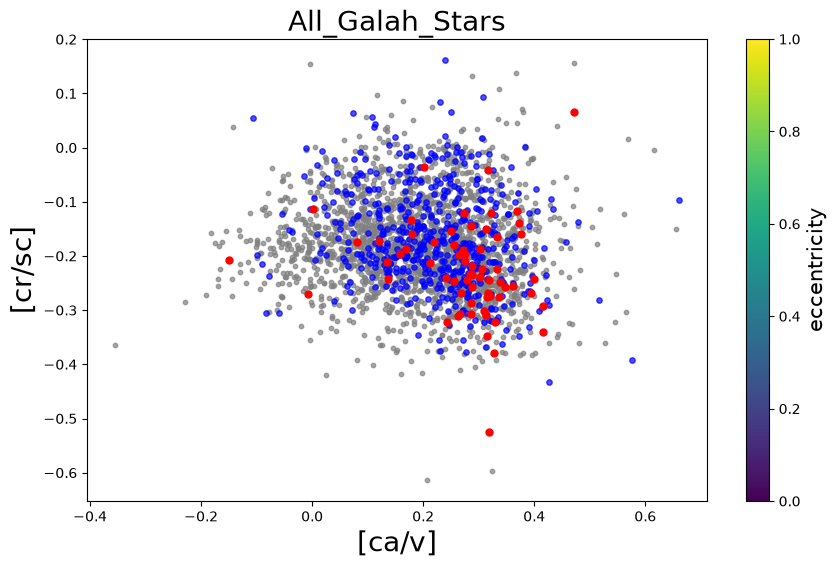

In [28]:
plt.figure(figsize=(10, 6))

# elm_ratio1 = 'fe_h'
# elm_ratio2 = 'si_fe'

elm_lable_x = elm_ratio1
elm_lable_y = elm_ratio2
for i in elm_lable_x:
    if i == '_':
        elm_lable_x = elm_lable_x.replace('_', '/')

for i in elm_lable_y:
    if i == '_':
        elm_lable_y = elm_lable_y.replace('_', '/')

# plt.scatter(galah_Gaia_raw_new_ratios[elm_ratio1], galah_Gaia_raw_new_ratios[elm_ratio2], 
#             c = galah_Gaia_raw_new_ratios['ecc_gaia'], #vmin = 0, vmax = 1,
#             # c = 'k',
#             label = 'All Galah', s = 1, alpha = 1)
plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2], 
            # c = galah_Gaia_Halo_new_ratios['ecc_gaia'], #vmin = 0, vmax = 1,
            c = 'grey',
            label = 'Halo', s = 10, alpha = 0.7)
plt.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], color = 'b', label = 'GSE', s = 15, alpha = 0.7)
plt.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], color = 'r', label = 'Sequoia', s = 25)


plt.title('All_Galah_Stars', fontsize = 20)
plt.xlabel(F'[{elm_lable_x}]', fontsize = 20)
plt.ylabel(F'[{elm_lable_y}]', fontsize  = 20)

# plt.xlabel(F'[Fe/H]', fontsize = 20)
# plt.ylabel(F'[Si/Fe]', fontsize  = 20)
# leg = plt.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
# for handle in leg.legend_handles:
#     handle.set_sizes([30])
# plt.xlim(-2.75,0.75)
cbar = plt.colorbar()
cbar.set_label('eccentricity', fontsize = 15)

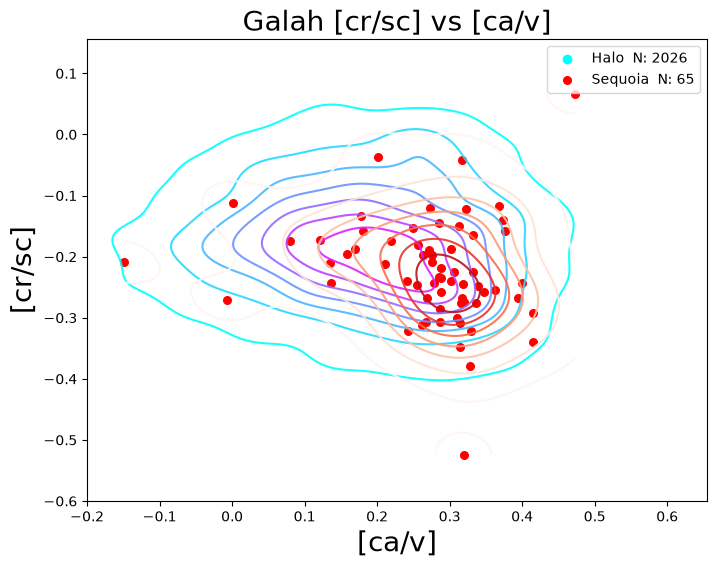

In [29]:
fig,ax = plt.subplots(figsize=(8, 6))

# plt.scatter(galah_Gaia_else_new_ratios[elm_ratio1], galah_Gaia_else_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)
# sns.kdeplot(
#     x=galah_Gaia_else_new_ratios[elm_ratio1].dropna(),
#     y=galah_Gaia_else_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greys',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
# )

# plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2],
#             # c = galah_Gaia_Halo_new_ratios['sc_v'], cmap = 'rainbow',s = 10,
#              color = 'grey', s = 40,
#              label = 'Halo', alpha = 0.9)
num = len(galah_Gaia_Halo_new_ratios)
plt.scatter(-3, -0.5, c = 'aqua', label = f'Halo  N: {num}')
sns.kdeplot(
    # x=(galah_Gaia_Halo_new_ratios[elm_ratio1]+ galah_Gaia_Halo_new_ratios[elm_ratio3]).dropna(),
    x= galah_Gaia_Halo_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_Halo_new_ratios[elm_ratio2]+ galah_Gaia_Halo_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_Halo_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='cool',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Halo'
)

# sc = ax.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], 
#                 # c = galah_Gaia_GSE_new_ratios['y_fe'], cmap = 'rainbow',
#                 color = 'green', 
#                 label = 'GSE', s = 40)
# sns.kdeplot(
#     # x=(galah_Gaia_GSE_new_ratios[elm_ratio1]+ galah_Gaia_GSE_new_ratios[elm_ratio3]).dropna(),
#     x= galah_Gaia_GSE_new_ratios[elm_ratio1].dropna(),
#     # y =(galah_Gaia_GSE_new_ratios[elm_ratio2]+ galah_Gaia_GSE_new_ratios[elm_ratio4]).dropna(),
#     y= galah_Gaia_GSE_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greens',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
#     label = 'GSE'
# )

num = len(galah_Gaia_Sequoia_new_ratios)

ax.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], 
        #    c = galah_Gaia_Sequoia_new_ratios['y_fe'], cmap = 'rainbow',
           color = 'red', 
           label = f'Sequoia  N: {num}', s = 30)
sns.kdeplot(
    # x=(galah_Gaia_Sequoia_new_ratios[elm_ratio1]+ galah_Gaia_Sequoia_new_ratios[elm_ratio3]).dropna(),
        x=galah_Gaia_Sequoia_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_Sequoia_new_ratios[elm_ratio2]+ galah_Gaia_Sequoia_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_Sequoia_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Reds',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Sequoia'
)

# ax.scatter(Sequoia_chem_selected[elm_ratio1], Sequoia_chem_selected[elm_ratio2], label = 'chemically selected "Sequoia" stars', )
# ax.scatter(0.52, -0.8)
# ax.scatter(0.52, -0.5)
# ax.scatter(0.62, -0.8)

# ax.scatter(v_mean + 0.02, sc_mean - 0.14, color = 'k', s = 40)
# all_x_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio2])

# H_VS_S_X_Low, H_VS_S_X_High = -1.2, None
H_VS_S_X_Low, H_VS_S_X_High = -0.2, None

# H_VS_S_Y_Low, H_VS_S_Y_High = None, None
H_VS_S_Y_Low, H_VS_S_Y_High = -0.6, None


ax.set_xlim(H_VS_S_X_Low, H_VS_S_X_High)
ax.set_ylim(H_VS_S_Y_Low, H_VS_S_Y_High)
ax.set_xlabel(F'[{elm_lable_x}]', fontsize=20)
ax.set_ylabel(F'[{elm_lable_y}]', fontsize=20)

# ax.set_ylabel(F'[Cr/Sc]', fontsize=20)
# ax.set_xlabel(F'[Ca/V]', fontsize=20)
leg = ax.legend(fontsize=15, labelspacing=0.8, borderpad=1.2)
ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([30])

    ax.set_title(F'Galah [{elm_lable_y}] vs [{elm_lable_x}]', fontsize=20)
    # ax.set_title(F'Galah [Cr/Sc] vs [Ca/V]', fontsize=20)

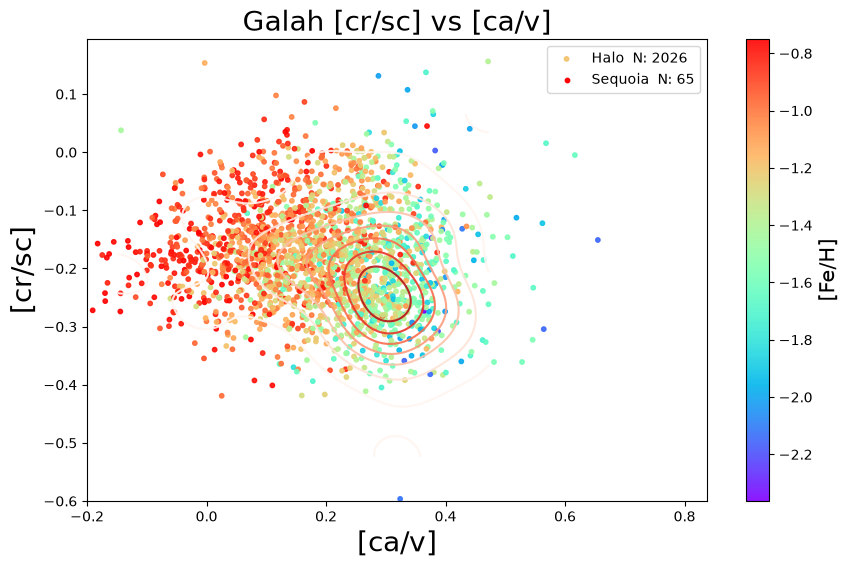

In [30]:
fig,ax = plt.subplots(figsize=(10, 6))

# plt.scatter(galah_Gaia_else_new_ratios[elm_ratio1], galah_Gaia_else_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)
# sns.kdeplot(
#     x=galah_Gaia_else_new_ratios[elm_ratio1].dropna(),
#     y=galah_Gaia_else_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greys',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
# )

num = len(galah_Gaia_Halo_new_ratios)
sc = plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2],
            c = galah_Gaia_Halo_new_ratios['fe_h'], cmap = 'rainbow',s = 10,
            #  color = 'grey', s = 40,
             label = f'Halo  N: {num}', alpha = 0.9)

# plt.scatter(-3, -0.5, c = 'aqua', label = f'Halo  N: {num}')
# sns.kdeplot(
#     # x=(galah_Gaia_Halo_new_ratios[elm_ratio1]+ galah_Gaia_Halo_new_ratios[elm_ratio3]).dropna(),
#     x= galah_Gaia_Halo_new_ratios[elm_ratio1].dropna(),
#     # y =(galah_Gaia_Halo_new_ratios[elm_ratio2]+ galah_Gaia_Halo_new_ratios[elm_ratio4]).dropna(),
#     y= galah_Gaia_Halo_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='cool',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
#     label = 'Halo'
# )

# sc = ax.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], 
#                 # c = galah_Gaia_GSE_new_ratios['y_fe'], cmap = 'rainbow',
#                 color = 'green', 
#                 label = 'GSE', s = 40)
# sns.kdeplot(
#     # x=(galah_Gaia_GSE_new_ratios[elm_ratio1]+ galah_Gaia_GSE_new_ratios[elm_ratio3]).dropna(),
#     x= galah_Gaia_GSE_new_ratios[elm_ratio1].dropna(),
#     # y =(galah_Gaia_GSE_new_ratios[elm_ratio2]+ galah_Gaia_GSE_new_ratios[elm_ratio4]).dropna(),
#     y= galah_Gaia_GSE_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greens',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
#     label = 'GSE'
# )

num = len(galah_Gaia_Sequoia_new_ratios)

# ax.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], 
#         #    c = galah_Gaia_Sequoia_new_ratios['y_fe'], cmap = 'rainbow',
#            color = 'red', 
#            label = f'Sequoia  N: {num}', s = 30)
plt.scatter(-3, -0.5, c = 'red', label = f'Sequoia  N: {num}', s =10)
sns.kdeplot(
    # x=(galah_Gaia_Sequoia_new_ratios[elm_ratio1]+ galah_Gaia_Sequoia_new_ratios[elm_ratio3]).dropna(),
        x=galah_Gaia_Sequoia_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_Sequoia_new_ratios[elm_ratio2]+ galah_Gaia_Sequoia_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_Sequoia_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Reds',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Sequoia'
)

# ax.scatter(Sequoia_chem_selected[elm_ratio1], Sequoia_chem_selected[elm_ratio2], label = 'chemically selected "Sequoia" stars', )
# ax.scatter(0.52, -0.8)
# ax.scatter(0.52, -0.5)
# ax.scatter(0.62, -0.8)

# ax.scatter(v_mean + 0.02, sc_mean - 0.14, color = 'k', s = 40)
# all_x_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio2])

ax.set_xlim(H_VS_S_X_Low, H_VS_S_X_High)
ax.set_ylim(H_VS_S_Y_Low, H_VS_S_Y_High)
ax.set_xlabel(F'[{elm_lable_x}]', fontsize=20)
ax.set_ylabel(F'[{elm_lable_y}]', fontsize=20)


# ax.set_ylabel(F'[Cr/Sc]', fontsize=20)
# ax.set_xlabel(F'[Ca/V]', fontsize=20)
leg = ax.legend(fontsize=15, labelspacing=0.8, borderpad=1.2)
ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([30])

    ax.set_title(F'Galah [{elm_lable_y}] vs [{elm_lable_x}]', fontsize=20)
    # ax.set_title(F'Galah [Cr/Sc] vs [Ca/V]', fontsize=20)

cbar = plt.colorbar(sc)
cbar.set_label('[Fe/H]', fontsize = 15)

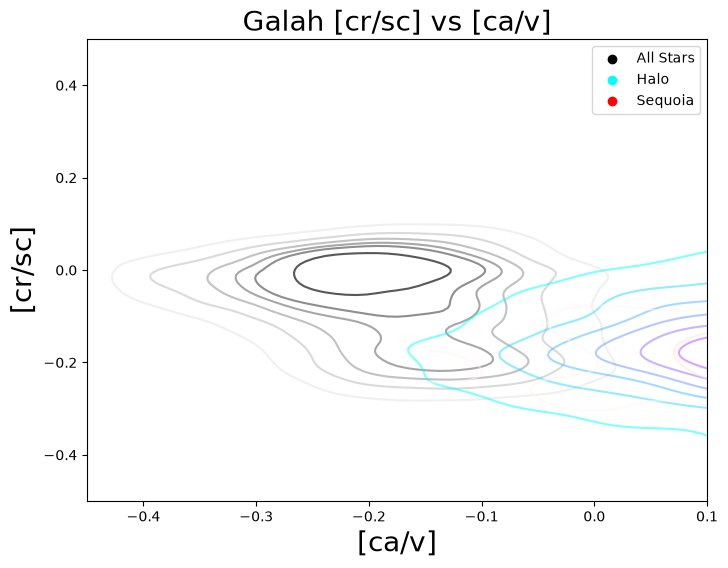

In [31]:
fig,ax = plt.subplots(figsize=(8, 6))

# plt.scatter(galah_Gaia_else_new_ratios[elm_ratio1], galah_Gaia_else_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)
plt.scatter(-3, -0.5, c = 'k', label = 'All Stars')
sns.kdeplot(
    x=galah_Gaia_else_new_ratios[elm_ratio1].dropna(),
    y=galah_Gaia_else_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Greys',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=1.0,
    ax=ax,
)

# plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2],
#             # c = galah_Gaia_Halo_new_ratios['sc_v'], cmap = 'rainbow',s = 10,
#              color = 'grey', s = 40,
#              label = 'Halo', alpha = 0.9)
plt.scatter(-3, -0.5, c = 'aqua', label = 'Halo')
sns.kdeplot(
    # x=(galah_Gaia_Halo_new_ratios[elm_ratio1]+ galah_Gaia_Halo_new_ratios[elm_ratio3]).dropna(),
    x= galah_Gaia_Halo_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_Halo_new_ratios[elm_ratio2]+ galah_Gaia_Halo_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_Halo_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='cool',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.5,
    ax=ax,
    label = 'Halo'
)

# sc = ax.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], 
#                 # c = galah_Gaia_GSE_new_ratios['y_fe'], cmap = 'rainbow',
#                 color = 'green', 
#                 label = 'GSE', s = 40)
# sns.kdeplot(
#     # x=(galah_Gaia_GSE_new_ratios[elm_ratio1]+ galah_Gaia_GSE_new_ratios[elm_ratio3]).dropna(),
#     x= galah_Gaia_GSE_new_ratios[elm_ratio1].dropna(),
#     # y =(galah_Gaia_GSE_new_ratios[elm_ratio2]+ galah_Gaia_GSE_new_ratios[elm_ratio4]).dropna(),
#     y= galah_Gaia_GSE_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greens',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
#     label = 'GSE'
# )

num = len(galah_Gaia_Sequoia_new_ratios)

# ax.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], 
#         #    c = galah_Gaia_Sequoia_new_ratios['y_fe'], cmap = 'rainbow',
#            color = 'red', 
#            label = f'Sequoia  N: {num}', s = 30)
plt.scatter(-3, -0.5, c = 'r', label = 'Sequoia')
sns.kdeplot(
    # x=(galah_Gaia_Sequoia_new_ratios[elm_ratio1]+ galah_Gaia_Sequoia_new_ratios[elm_ratio3]).dropna(),
        x=galah_Gaia_Sequoia_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_Sequoia_new_ratios[elm_ratio2]+ galah_Gaia_Sequoia_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_Sequoia_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Reds',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.5,
    ax=ax,
    label = 'Sequoia'
)

# ax.scatter(Sequoia_chem_selected[elm_ratio1], Sequoia_chem_selected[elm_ratio2], label = 'chemically selected "Sequoia" stars', )
# ax.scatter(0.52, -0.8)
# ax.scatter(0.52, -0.5)
# ax.scatter(0.62, -0.8)

# ax.scatter(v_mean + 0.02, sc_mean - 0.14, color = 'k', s = 40)
# all_x_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio2])


# ax.set_xlim(H_VS_S_X_Low, 0.5)
# ax.set_ylim(-0.8, 0.65)
ax.set_xlim(-0.45, 0.1)
ax.set_ylim(-0.5, 0.5)

ax.set_xlabel(F'[{elm_lable_x}]', fontsize=20)
ax.set_ylabel(F'[{elm_lable_y}]', fontsize=20)
leg = ax.legend(fontsize=15, labelspacing=0.8, borderpad=1.2)
ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([30])
    ax.set_title(F'Galah [{elm_lable_y}] vs [{elm_lable_x}]', fontsize=20)

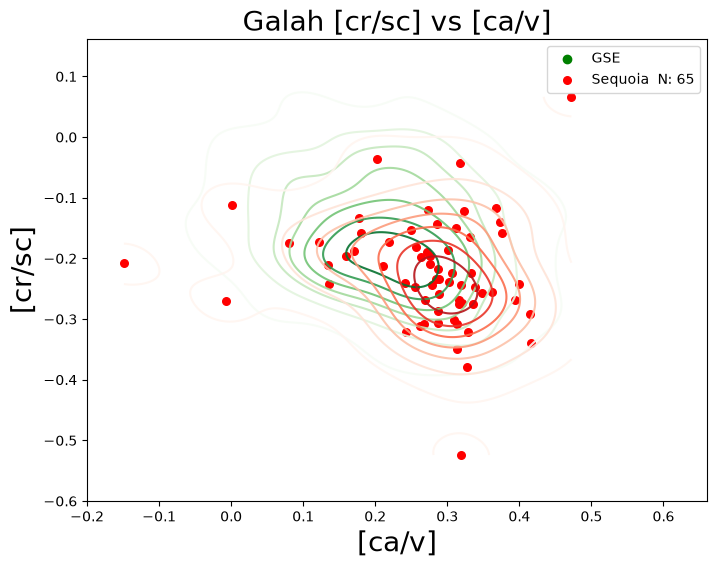

In [32]:
fig,ax = plt.subplots(figsize=(8, 6))

# plt.scatter(galah_Gaia_else_new_ratios[elm_ratio1], galah_Gaia_else_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)
# sns.kdeplot(
#     x=galah_Gaia_else_new_ratios[elm_ratio1].dropna(),
#     y=galah_Gaia_else_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greys',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=1.0,
#     ax=ax,
# )

# plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2],
#             # c = galah_Gaia_Halo_new_ratios['sc_v'], cmap = 'rainbow',s = 10,
#              color = 'grey', s = 40,
#              label = 'Halo', alpha = 0.9)
# sns.kdeplot(
#     # x=(galah_Gaia_Halo_new_ratios[elm_ratio1]+ galah_Gaia_Halo_new_ratios[elm_ratio3]).dropna(),
#     x= galah_Gaia_Halo_new_ratios[elm_ratio1].dropna(),
#     # y =(galah_Gaia_Halo_new_ratios[elm_ratio2]+ galah_Gaia_Halo_new_ratios[elm_ratio4]).dropna(),
#     y= galah_Gaia_Halo_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='cool',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.5,
#     ax=ax,
#     label = 'Halo'
# )

# sc = ax.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], 
#                 # c = galah_Gaia_GSE_new_ratios['y_fe'], cmap = 'rainbow',
#                 color = 'green', 
#                 label = 'GSE', s = 40)
plt.scatter(-3, -0.5, c = 'green', label = 'GSE')
sns.kdeplot(
    # x=(galah_Gaia_GSE_new_ratios[elm_ratio1]+ galah_Gaia_GSE_new_ratios[elm_ratio3]).dropna(),
    x= galah_Gaia_GSE_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_GSE_new_ratios[elm_ratio2]+ galah_Gaia_GSE_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_GSE_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Greens',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'GSE'
)

num = len(galah_Gaia_Sequoia_new_ratios)

ax.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], 
        #    c = galah_Gaia_Sequoia_new_ratios['y_fe'], cmap = 'rainbow',
           color = 'red', 
           label = f'Sequoia  N: {num}', s = 30)
sns.kdeplot(
    # x=(galah_Gaia_Sequoia_new_ratios[elm_ratio1]+ galah_Gaia_Sequoia_new_ratios[elm_ratio3]).dropna(),
        x=galah_Gaia_Sequoia_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_Sequoia_new_ratios[elm_ratio2]+ galah_Gaia_Sequoia_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_Sequoia_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Reds',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Sequoia'
)

# ax.scatter(Sequoia_chem_selected[elm_ratio1], Sequoia_chem_selected[elm_ratio2], label = 'chemically selected "Sequoia" stars', )
# ax.scatter(0.52, -0.8)
# ax.scatter(0.52, -0.5)
# ax.scatter(0.62, -0.8)

# ax.scatter(v_mean + 0.02, sc_mean - 0.14, color = 'k', s = 40)
# all_x_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio2])
ax.set_xlim(H_VS_S_X_Low, H_VS_S_X_High)
ax.set_ylim(H_VS_S_Y_Low, H_VS_S_Y_High)
ax.set_xlabel(F'[{elm_lable_x}]', fontsize=20)
ax.set_ylabel(F'[{elm_lable_y}]', fontsize=20)
leg = ax.legend(fontsize=15, labelspacing=0.8, borderpad=1.2)
ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([30])
    ax.set_title(F'Galah [{elm_lable_y}] vs [{elm_lable_x}]', fontsize=20)

In [33]:
# galah_Gaia_new_ratios[combined_ratio_1] = (
#     galah_Gaia_new_ratios[ratio1]
#     + galah_Gaia_new_ratios[ratio2]
#     # + galah_Gaia_new_ratios[ratio3]
# )
# galah_Gaia_new_ratios[combined_ratio_2] = (
#     galah_Gaia_new_ratios[ratio4]
#     + galah_Gaia_new_ratios[ratio5]
#     + galah_Gaia_new_ratios[ratio6]
# )

# X = galah_Gaia_new_ratios[combined_ratio_1]
# Y = galah_Gaia_new_ratios[combined_ratio_2]


# Sequoia_chem_selected = galah_Gaia_new_ratios[
#                         (((((X-0.52)**2)/0.1**2) +(((Y + 0.8)**2)/0.3**2)) < 1)
#                     & (~galah_Gaia_new_ratios['gaiadr3_source_id'].isin(NGC3201_galah['gaiadr3_source_id']))
#                     & (~galah_Gaia_new_ratios['gaiadr3_source_id'].isin(NGC5139_galah['gaiadr3_source_id']))
# ]

# print(len(Sequoia_chem_selected))


# ax.scatter(0.52, -0.8)
# ax.scatter(0.52, -0.5)
# ax.scatter(0.62, -0.8)

In [ ]:

element_list_partial_small_galah_7 = [ 'fe', 'cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_2 = ['cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_3 = ['fe', 'v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_7_4 = ['fe', 'si', 'nd', 'na', 'mg', 'k', 'ca', 'sc', 'ti', 'v', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba']
element_list_partial_small_galah_7_5 = ['v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_10 = ['fe', 'v', 'sc', 'si', 'ca', 'mn', 'na', 'nd']
element_list_partial_small_galah_11 = ['y', 'v', 'nd', 'si']

element_list = element_list_partial_small_galah_7_5
# element_list = element_list_partial_small_galah_11

galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia, element_list)

galah_Gaia_new_ratios = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0] # this ontains a full catalog from galah but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
galah_gaia_new_element_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]     # this just lists the new columns ratios so I can more easily call them
galah_gaia_new_element_ratio_errors_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[2] 

galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_GSE, element_list)
galah_Gaia_GSE_new_ratios = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_GSE, element_list)
galah_Gaia_Kushniruk_GSE_new_ratios = galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Sequoia, element_list)
galah_Gaia_Sequoia_new_ratios = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC3201_galah, element_list)
# galah_Gaia_NGC3201_new_ratios = galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC5139_galah, element_list)
# galah_Gaia_NGC5139_new_ratios = galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos1, element_list)
# galah_Gaia_Thamnos1_new_ratios = galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos2, element_list)
# galah_Gaia_Thamnos2_new_ratios = galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC1851_galah, element_list)
# galah_Gaia_NGC1851_new_ratios = galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Halo, element_list)
galah_Gaia_Halo_new_ratios = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_else_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_else, element_list)
galah_Gaia_else_new_ratios = galah_Gaia_else_new_ratios_catolog_ratiolist_ratioerrorlist[0]

In [ ]:
print(len(galah_Gaia_Sequoia_new_ratios))
print(len(galah_Gaia_GSE_new_ratios))
print(len(galah_Gaia_Halo_new_ratios))

In [ ]:
elm_ratio2 = 'eu_ba' ####  This might be good for separating the GSE and Sequoia
elm_ratio2 = 'cr_sc'
elm_ratio1 = 'nd_y'


elm_lable_x = elm_ratio1
elm_lable_y = elm_ratio2
for i in elm_lable_x:
    if i == '_':
        elm_lable_x = elm_lable_x.replace('_', '/')

for i in elm_lable_y:
    if i == '_':
        elm_lable_y = elm_lable_y.replace('_', '/')

X = galah_Gaia_Sequoia_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()
Y = galah_Gaia_GSE_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()

statistic, p_value = Energy().test(X, Y)
print(f'statistic: {statistic}, p-value: {p_value},  for {elm_lable_x} vs {elm_lable_y}')

In [ ]:
sample1 = galah_Gaia_Sequoia_new_ratios[elm_ratio1]
sample2 = galah_Gaia_GSE_new_ratios[elm_ratio1]

statistic, p_value = kstest(sample1, sample2)
print(f'statistic: {statistic}, p-value: {p_value},  for {elm_ratio1}')

In [ ]:
for df in [
    galah_Gaia_Sequoia_new_ratios,
    galah_Gaia_GSE_new_ratios,
    galah_Gaia_Halo_new_ratios,
    galah_Gaia_else_new_ratios,
]:
    df['ca_cr'] = -df['cr_ca']

In [ ]:
# ratio1 = 'nd_y'
# ratio2 = 'mn_sc'
# # ratio3 = 'ti_v'
# ratio4 = 'si_v'
# ratio5 = 'ca_cr'
# # ratio6 = 'na_sc'

# combined_ratio_1 = f'{ratio1} + {ratio2}'#_p_{ratio3}'
# combined_ratio_2 = f'{ratio4} + {ratio5}'#_p_{ratio6}'

# elm_ratio1 = combined_ratio_1
# elm_ratio2 = combined_ratio_2

# elm_lable_x = elm_ratio1
# elm_lable_y = elm_ratio2
# for i in elm_lable_x:
#     if i == '_':
#         elm_lable_x = elm_lable_x.replace('_', '/')

# for i in elm_lable_y:
#     if i == '_':
#         elm_lable_y = elm_lable_y.replace('_', '/')


# for df in [
#     galah_Gaia_Sequoia_new_ratios,
#     galah_Gaia_Halo_new_ratios,
#     galah_Gaia_GSE_new_ratios,
#     galah_Gaia_else_new_ratios,
# ]:
#     df[combined_ratio_1] = df[ratio1] + df[ratio2]# + df[ratio3]
#     df[combined_ratio_2] = df[ratio4] + df[ratio5]# + df[ratio6]

# X = galah_Gaia_Sequoia_new_ratios[[combined_ratio_1, combined_ratio_2]].dropna().to_numpy()
# Y = galah_Gaia_GSE_new_ratios[[combined_ratio_1, combined_ratio_2]].dropna().to_numpy()

# statistic, p_value = Energy().test(X, Y)
# print(f'statistic: {statistic}, p-value: {p_value},  for {elm_lable_x} vs {elm_lable_y}')

In [ ]:
fig,ax = plt.subplots(figsize=(10, 6))

# plt.scatter(galah_Gaia_else_new_ratios[elm_ratio1], galah_Gaia_else_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)
# sns.kdeplot(
#     x=galah_Gaia_else_new_ratios[elm_ratio1].dropna(),
#     y=galah_Gaia_else_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greys',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
# )

# plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2],
#             # c = galah_Gaia_Halo_new_ratios['sc_v'], cmap = 'rainbow',s = 10,
#              color = 'grey', s = 40,
#              label = 'Halo', alpha = 0.9)
# sns.kdeplot(
#     # x=(galah_Gaia_Halo_new_ratios[elm_ratio1]+ galah_Gaia_Halo_new_ratios[elm_ratio3]).dropna(),
#     x= galah_Gaia_Halo_new_ratios[elm_ratio1].dropna(),
#     # y =(galah_Gaia_Halo_new_ratios[elm_ratio2]+ galah_Gaia_Halo_new_ratios[elm_ratio4]).dropna(),
#     y= galah_Gaia_Halo_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='cool',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
#     label = 'Halo'
# )

# sc = ax.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], 
#                 # c = galah_Gaia_GSE_new_ratios['y_fe'], cmap = 'rainbow',
#                 color = 'green', 
#                 label = 'GSE', s = 40)
num = len(galah_Gaia_GSE_new_ratios)
plt.scatter(-3, -0.5, c = 'g', label = f'GSE  N: {num}')
sns.kdeplot(
    # x=(galah_Gaia_GSE_new_ratios[elm_ratio1]+ galah_Gaia_GSE_new_ratios[elm_ratio3]).dropna(),
    x= galah_Gaia_GSE_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_GSE_new_ratios[elm_ratio2]+ galah_Gaia_GSE_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_GSE_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Greens',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'GSE'
)

num = len(galah_Gaia_Sequoia_new_ratios)

ax.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], 
        #    c = galah_Gaia_Sequoia_new_ratios['fe_h'], cmap = 'rainbow',
           color = 'red', 
           label = f'Sequoia  N: {num}', s = 30)
sns.kdeplot(
    # x=(galah_Gaia_Sequoia_new_ratios[elm_ratio1]+ galah_Gaia_Sequoia_new_ratios[elm_ratio3]).dropna(),
        x=galah_Gaia_Sequoia_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_Sequoia_new_ratios[elm_ratio2]+ galah_Gaia_Sequoia_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_Sequoia_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Reds',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Sequoia'
)

# ax.scatter(v_mean + 0.02, sc_mean - 0.14, color = 'k', s = 40)
# all_x_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio2])

# G_vs_S_X_Low,G_vs_S_X_High, G_vs_S_Y_Low, G_vs_S_Y_high = -1.5, 0.6, 0.2, None
G_vs_S_X_Low,G_vs_S_X_High, G_vs_S_Y_Low, G_vs_S_Y_high = -0.4, 1.0, None, None

ax.set_xlim(G_vs_S_X_Low, G_vs_S_X_High)
ax.set_ylim(G_vs_S_Y_Low, G_vs_S_Y_high)
ax.set_xlabel(F'[{elm_lable_x}]', fontsize=20)
ax.set_ylabel(F'[{elm_lable_y}]', fontsize=20)


ax.set_xlabel(F'[Nd/Y]', fontsize=20)
ax.set_ylabel(F'[Cr/Sc]', fontsize=20)
leg = ax.legend(fontsize=15, labelspacing=0.8, borderpad=1.2)
ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([30])
    ax.set_title(F'Galah [{elm_lable_y}] vs [{elm_lable_x}]', fontsize=20)
    ax.set_title(F'Galah [Cr/Sc] vs [Nd/Y]', fontsize=20)

In [ ]:
fig,ax = plt.subplots(figsize=(10, 6))

# plt.scatter(galah_Gaia_else_new_ratios[elm_ratio1], galah_Gaia_else_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)
# sns.kdeplot(
#     x=galah_Gaia_else_new_ratios[elm_ratio1].dropna(),
#     y=galah_Gaia_else_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greys',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
# )

# plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2],
#             # c = galah_Gaia_Halo_new_ratios['sc_v'], cmap = 'rainbow',s = 10,
#              color = 'grey', s = 40,
#              label = 'Halo', alpha = 0.9)
# sns.kdeplot(
#     # x=(galah_Gaia_Halo_new_ratios[elm_ratio1]+ galah_Gaia_Halo_new_ratios[elm_ratio3]).dropna(),
#     x= galah_Gaia_Halo_new_ratios[elm_ratio1].dropna(),
#     # y =(galah_Gaia_Halo_new_ratios[elm_ratio2]+ galah_Gaia_Halo_new_ratios[elm_ratio4]).dropna(),
#     y= galah_Gaia_Halo_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='cool',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
#     label = 'Halo'
# )
num = len(galah_Gaia_GSE_new_ratios)
sc = ax.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], 
                c = galah_Gaia_GSE_new_ratios['fe_h'], cmap = 'rainbow',
                # color = 'green', 
                label = f'GSE  N: {num}', s = 40)

# plt.scatter(-3, -0.5, c = 'g', label = f'GSE  N: {num}')
sns.kdeplot(
    # x=(galah_Gaia_GSE_new_ratios[elm_ratio1]+ galah_Gaia_GSE_new_ratios[elm_ratio3]).dropna(),
    x= galah_Gaia_GSE_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_GSE_new_ratios[elm_ratio2]+ galah_Gaia_GSE_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_GSE_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Greens',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'GSE'
)

num = len(galah_Gaia_Sequoia_new_ratios)

# ax.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], 
#         #    c = galah_Gaia_Sequoia_new_ratios['y_fe'], cmap = 'rainbow',
#            color = 'red', 
#            label = f'Sequoia  N: {num}', s = 30)
sns.kdeplot(
    # x=(galah_Gaia_Sequoia_new_ratios[elm_ratio1]+ galah_Gaia_Sequoia_new_ratios[elm_ratio3]).dropna(),
        x=galah_Gaia_Sequoia_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_Sequoia_new_ratios[elm_ratio2]+ galah_Gaia_Sequoia_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_Sequoia_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Reds',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Sequoia'
)

# ax.scatter(v_mean + 0.02, sc_mean - 0.14, color = 'k', s = 40)
# all_x_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio2])

ax.set_xlim(G_vs_S_X_Low, G_vs_S_X_High)
ax.set_ylim(G_vs_S_Y_Low, G_vs_S_Y_high)
ax.set_xlabel(F'[{elm_lable_x}]', fontsize=20)
ax.set_ylabel(F'[{elm_lable_y}]', fontsize=20)
leg = ax.legend(fontsize=15, labelspacing=0.8, borderpad=1.2)
ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([30])
    ax.set_title(F'Galah [{elm_lable_y}] vs [{elm_lable_x}]', fontsize=20)

cbar = plt.colorbar(sc)
cbar.set_label('[fe/h]', fontsize = 15)

In [ ]:
fig,ax = plt.subplots(figsize=(10, 6))

# plt.scatter(galah_Gaia_else_new_ratios[elm_ratio1], galah_Gaia_else_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)
# sns.kdeplot(
#     x=galah_Gaia_else_new_ratios[elm_ratio1].dropna(),
#     y=galah_Gaia_else_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greys',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
# )


# plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2],
#             # c = galah_Gaia_Halo_new_ratios['sc_v'], cmap = 'rainbow',s = 10,
#              color = 'grey', s = 40,
#              label = 'Halo', alpha = 0.9)
plt.scatter(-3, -0.5, c = 'aqua', label = 'Halo')
sns.kdeplot(
    # x=(galah_Gaia_Halo_new_ratios[elm_ratio1]+ galah_Gaia_Halo_new_ratios[elm_ratio3]).dropna(),
    x= galah_Gaia_Halo_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_Halo_new_ratios[elm_ratio2]+ galah_Gaia_Halo_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_Halo_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='cool',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Halo'
)

# sc = ax.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], 
#                 # c = galah_Gaia_GSE_new_ratios['y_fe'], cmap = 'rainbow',
#                 color = 'green', 
#                 label = 'GSE', s = 40)
plt.scatter(-3, -0.5, c = 'g', label = 'GSE')
sns.kdeplot(
    # x=(galah_Gaia_GSE_new_ratios[elm_ratio1]+ galah_Gaia_GSE_new_ratios[elm_ratio3]).dropna(),
    x= galah_Gaia_GSE_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_GSE_new_ratios[elm_ratio2]+ galah_Gaia_GSE_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_GSE_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Greens',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'GSE'
)

num = len(galah_Gaia_Sequoia_new_ratios)

# ax.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], 
#         #    c = galah_Gaia_Sequoia_new_ratios['y_fe'], cmap = 'rainbow',
#            color = 'red', 
#            label = f'Sequoia  N: {num}', s = 30)
plt.scatter(-3, -0.5, c = 'r', label = 'Sequoia')
sns.kdeplot(
    # x=(galah_Gaia_Sequoia_new_ratios[elm_ratio1]+ galah_Gaia_Sequoia_new_ratios[elm_ratio3]).dropna(),
        x=galah_Gaia_Sequoia_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_Sequoia_new_ratios[elm_ratio2]+ galah_Gaia_Sequoia_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_Sequoia_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Reds',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Sequoia'
)

# ax.scatter(v_mean + 0.02, sc_mean - 0.14, color = 'k', s = 40)
# all_x_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio2])
ax.set_xlim(G_vs_S_X_Low, G_vs_S_X_High)
ax.set_ylim(G_vs_S_Y_Low, G_vs_S_Y_high)
ax.set_xlabel(F'[{elm_lable_x}]', fontsize = 20)
ax.set_ylabel(F'[{elm_lable_y}]', fontsize = 20)
leg = ax.legend(fontsize=15, labelspacing=0.8, borderpad=1.2)
ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([30])
    ax.set_title(F'Galah [{elm_lable_y}] vs [{elm_lable_x}]', fontsize = 20)

In [ ]:
fig,ax = plt.subplots(figsize=(8, 6))

# plt.scatter(galah_Gaia_else_new_ratios[elm_ratio1], galah_Gaia_else_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)
plt.scatter(-3, -0.5, c = 'k', label = 'All Stars')
sns.kdeplot(
    x=galah_Gaia_else_new_ratios[elm_ratio1].dropna(),
    y=galah_Gaia_else_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Greys',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
)

# plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2],
#             # c = galah_Gaia_Halo_new_ratios['sc_v'], cmap = 'rainbow',s = 10,
#              color = 'grey', s = 40,
#              label = 'Halo', alpha = 0.9)
# sns.kdeplot(
#     # x=(galah_Gaia_Halo_new_ratios[elm_ratio1]+ galah_Gaia_Halo_new_ratios[elm_ratio3]).dropna(),
#     x= galah_Gaia_Halo_new_ratios[elm_ratio1].dropna(),
#     # y =(galah_Gaia_Halo_new_ratios[elm_ratio2]+ galah_Gaia_Halo_new_ratios[elm_ratio4]).dropna(),
#     y= galah_Gaia_Halo_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='cool',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
#     label = 'Halo'
# )

# sc = ax.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], 
#                 # c = galah_Gaia_GSE_new_ratios['y_fe'], cmap = 'rainbow',
#                 color = 'green', 
#                 label = 'GSE', s = 40)
plt.scatter(-3, -0.5, c = 'g', label = 'GSE')
sns.kdeplot(
    # x=(galah_Gaia_GSE_new_ratios[elm_ratio1]+ galah_Gaia_GSE_new_ratios[elm_ratio3]).dropna(),
    x= galah_Gaia_GSE_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_GSE_new_ratios[elm_ratio2]+ galah_Gaia_GSE_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_GSE_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Greens',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'GSE'
)

num = len(galah_Gaia_Sequoia_new_ratios)

# ax.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], 
#         #    c = galah_Gaia_Sequoia_new_ratios['y_fe'], cmap = 'rainbow',
#            color = 'red', 
#            label = f'Sequoia  N: {num}', s = 30)
plt.scatter(-3, -0.5, c = 'r', label = 'Sequoia')
sns.kdeplot(
    # x=(galah_Gaia_Sequoia_new_ratios[elm_ratio1]+ galah_Gaia_Sequoia_new_ratios[elm_ratio3]).dropna(),
        x=galah_Gaia_Sequoia_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_Sequoia_new_ratios[elm_ratio2]+ galah_Gaia_Sequoia_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_Sequoia_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Reds',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Sequoia'
)

# ax.scatter(v_mean + 0.02, sc_mean - 0.14, color = 'k', s = 40)
# all_x_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio2])

# ax.set_xlim(-1.0, G_vs_S_X_High) # I can't use the (G_vs_S_X_Low, G_vs_S_X_high) because the else part is far too spread out
# ax.set_ylim(-0.5, 0.9) # I can't use the (G_vs_S_Y_Low, G_vs_S_Y_high) because the else part is far too spread out


ax.set_xlim(G_vs_S_X_Low, G_vs_S_X_High) # I can't use the (G_vs_S_X_Low, G_vs_S_X_high) because the else part is far too spread out
ax.set_ylim(-0.5, 0.1) # I can't use the (G_vs_S_Y_Low, G_vs_S_Y_high) because the else part is far too spread out

ax.set_xlabel(F'[{elm_lable_x}]', fontsize = 20)
ax.set_ylabel(F'[{elm_lable_y}]', fontsize = 20)
leg = ax.legend(fontsize=10, labelspacing=0.8, borderpad=1.2)
ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([30])
    ax.set_title(F'Galah [{elm_lable_y}] vs [{elm_lable_x}]', fontsize = 20)

In [ ]:

element_list_partial_small_galah_7 = [ 'fe', 'cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_2 = ['cu', 'ca', 'mn', 'ti', 'y', 'ni', 'zn', 'v', 'ba','na', 'nd', 'si', 'k', 'sc', 'cr', 'co']
element_list_partial_small_galah_7_3 = ['fe', 'v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_7_4 = ['fe', 'si', 'nd', 'na', 'mg', 'k', 'ca', 'sc', 'ti', 'v', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba']
element_list_partial_small_galah_7_5 = ['v', 'sc', 'na', 'mg', 'si', 'k', 'ca', 'ti', 'cr', 'mn', 'co', 'ni', 'cu', 'zn', 'y', 'ba', 'nd']
element_list_partial_small_galah_10 = ['fe', 'v', 'sc', 'si', 'ca', 'mn', 'na', 'nd']
element_list_partial_small_galah_11 = ['y', 'v', 'nd', 'si']

element_list = element_list_partial_small_galah_7_5
# element_list = element_list_partial_small_galah_11

galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia, element_list)

galah_Gaia_new_ratios = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[0] # this ontains a full catalog from galah but now it includes ratios for Ca, Si, Ti, Ni, Zr, Ce, and Nd relative to eachother: Pradosh did recomend taking out
                                                                 # Si, and Ni whitch I can do by changing "element_list_partial_large" to element_list_partial_small
galah_gaia_new_element_ratio_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[1]     # this just lists the new columns ratios so I can more easily call them
galah_gaia_new_element_ratio_errors_list = galah_Gaia_new_ratios_catolog_ratiolist_ratioerrorlist[2] 

galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_GSE, element_list)
galah_Gaia_GSE_new_ratios = galah_Gaia_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_GSE, element_list)
galah_Gaia_Kushniruk_GSE_new_ratios = galah_Gaia_Kushniruk_GSE_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Sequoia, element_list)
galah_Gaia_Sequoia_new_ratios = galah_Gaia_Sequoia_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC3201_galah, element_list)
# galah_Gaia_NGC3201_new_ratios = galah_Gaia_NGC3201_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC5139_galah, element_list)
# galah_Gaia_NGC5139_new_ratios = galah_Gaia_NGC5139_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos1, element_list)
# galah_Gaia_Thamnos1_new_ratios = galah_Gaia_Thamnos1_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Kushniruk_Thamnos2, element_list)
# galah_Gaia_Thamnos2_new_ratios = galah_Gaia_Thamnos2_new_ratios_catolog_ratiolist_ratioerrorlist[0]

# galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(NGC1851_galah, element_list)
# galah_Gaia_NGC1851_new_ratios = galah_Gaia_NGC1851_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_Halo, element_list)
galah_Gaia_Halo_new_ratios = galah_Gaia_Halo_new_ratios_catolog_ratiolist_ratioerrorlist[0]

galah_Gaia_else_new_ratios_catolog_ratiolist_ratioerrorlist = make_elm_ratio_combinations_galah(galah_Gaia_else, element_list)
galah_Gaia_else_new_ratios = galah_Gaia_else_new_ratios_catolog_ratiolist_ratioerrorlist[0]

In [ ]:
galah_Gaia_Halo_new_ratios = Halo_Pradosh_galah_Gaia

elm_ratio2 = 'eu_ba' ####  This might be good for separating the GSE and Sequoia
elm_ratio2 = 'mn_na'
elm_ratio1 = 'nd_y'


elm_lable_x = elm_ratio1
elm_lable_y = elm_ratio2
for i in elm_lable_x:
    if i == '_':
        elm_lable_x = elm_lable_x.replace('_', '/')

for i in elm_lable_y:
    if i == '_':
        elm_lable_y = elm_lable_y.replace('_', '/')

X = galah_Gaia_Halo_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()
Y = galah_Gaia_GSE_new_ratios[[elm_ratio1, elm_ratio2]].dropna().to_numpy()

statistic, p_value = Energy().test(X, Y)
print(f'statistic: {statistic}, p-value: {p_value},  for {elm_lable_x} vs {elm_lable_y}')

In [ ]:
fig,ax = plt.subplots(figsize=(10, 6))

# plt.scatter(galah_Gaia_else_new_ratios[elm_ratio1], galah_Gaia_else_new_ratios[elm_ratio2], color = 'grey', label = 'All Galah', s = 0.3, alpha = 0.2)
# sns.kdeplot(
#     x=galah_Gaia_else_new_ratios[elm_ratio1].dropna(),
#     y=galah_Gaia_else_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Greys',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
# )

# num = len(galah_Gaia_Halo_new_ratios)
# plt.scatter(galah_Gaia_Halo_new_ratios[elm_ratio1], galah_Gaia_Halo_new_ratios[elm_ratio2],
#             c = galah_Gaia_Halo_new_ratios['fe_h'], cmap = 'rainbow',s = 10, #markershape = 'o',
#             #  color = 'grey', s = 40,
#              label = f'Halo  N: {num}', alpha = 0.9)
# plt.scatter(-3, 0.1, c = 'aqua', label = f'Halo  N: {num}')
sns.kdeplot(
    # x=(galah_Gaia_Halo_new_ratios[elm_ratio1]+ galah_Gaia_Halo_new_ratios[elm_ratio3]).dropna(),
    x= galah_Gaia_Halo_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_Halo_new_ratios[elm_ratio2]+ galah_Gaia_Halo_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_Halo_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='cool',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=0.9,
    ax=ax,
    label = 'Halo'
)

# num = len(galah_Gaia_GSE_new_ratios)
# sc = ax.scatter(galah_Gaia_GSE_new_ratios[elm_ratio1], galah_Gaia_GSE_new_ratios[elm_ratio2], 
#                 c = galah_Gaia_GSE_new_ratios['fe_h'], cmap = 'rainbow', #shape = 'x',
#                 # color = 'green', 
#                 label = f'GSE  N: {num}', s = 10)

# plt.scatter(-3, 0.1, c = 'g', label = f'GSE  N: {num}')
sns.kdeplot(
    # x=(galah_Gaia_GSE_new_ratios[elm_ratio1]+ galah_Gaia_GSE_new_ratios[elm_ratio3]).dropna(),
    x= galah_Gaia_GSE_new_ratios[elm_ratio1].dropna(),
    # y =(galah_Gaia_GSE_new_ratios[elm_ratio2]+ galah_Gaia_GSE_new_ratios[elm_ratio4]).dropna(),
    y= galah_Gaia_GSE_new_ratios[elm_ratio2].dropna(),
    levels=8,
    cmap='Greens',
    thresh=0.05,
    fill=False,
    linewidths=1.5,
    cut=0,
    alpha=1.0,
    ax=ax,
    label = 'GSE'
)

# num = len(galah_Gaia_Sequoia_new_ratios)

# ax.scatter(galah_Gaia_Sequoia_new_ratios[elm_ratio1], galah_Gaia_Sequoia_new_ratios[elm_ratio2], 
#         #    c = galah_Gaia_Sequoia_new_ratios['fe_h'], cmap = 'rainbow',
#            color = 'red', 
#            label = f'Sequoia  N: {num}', s = 30)
# sns.kdeplot(
#     # x=(galah_Gaia_Sequoia_new_ratios[elm_ratio1]+ galah_Gaia_Sequoia_new_ratios[elm_ratio3]).dropna(),
#         x=galah_Gaia_Sequoia_new_ratios[elm_ratio1].dropna(),
#     # y =(galah_Gaia_Sequoia_new_ratios[elm_ratio2]+ galah_Gaia_Sequoia_new_ratios[elm_ratio4]).dropna(),
#     y= galah_Gaia_Sequoia_new_ratios[elm_ratio2].dropna(),
#     levels=8,
#     cmap='Reds',
#     thresh=0.05,
#     fill=False,
#     linewidths=1.5,
#     cut=0,
#     alpha=0.9,
#     ax=ax,
#     label = 'Sequoia'
# )

# ax.scatter(v_mean + 0.02, sc_mean - 0.14, color = 'k', s = 40)
# all_x_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio1])
# all_y_values.append(galah_Gaia_Sequoia_new_ratios[elm_ratio2])

# G_vs_H_X_Low,G_vs_H_X_High, G_vs_H_Y_Low, G_vs_H_Y_high = -1.5, 0.6, 0.2, None
G_vs_H_X_Low,G_vs_H_X_High, G_vs_H_Y_Low, G_vs_H_Y_high = -0.5, None, None, None

ax.set_xlim(G_vs_H_X_Low, G_vs_H_X_High)
ax.set_ylim(G_vs_H_Y_Low, G_vs_H_Y_high)
ax.set_xlabel(F'[{elm_lable_x}]', fontsize=20)
ax.set_ylabel(F'[{elm_lable_y}]', fontsize=20)


ax.set_xlabel(F'[Nd/Y]', fontsize=20)
ax.set_ylabel(F'[Cr/Na]', fontsize=20)
leg = ax.legend(fontsize=15, labelspacing=0.8, borderpad=1.2)
ax.legend()
for handle in leg.legend_handles:
    handle.set_sizes([30])
    ax.set_title(F'Galah [{elm_lable_y}] vs [{elm_lable_x}]', fontsize=20)
    ax.set_title(F'Galah [Cr/Na] vs [Nd/Y]', fontsize=20)
# plt.colorbar()